# 03 Architecture and Uncertainty Comparison

## Overview

This notebook compares the BERT BIO and SpanNER branches of the dissertation pipeline using the frozen validation population established in Notebook 00 and the final model outputs generated in Notebooks 01 and 02.

The first part of the analysis compares the two architectures at the task level, including strict typed-span performance, entity-level error profiles and boundary-specific errors. Because SpanNER is restricted to candidate spans of at most four words whereas BERT BIO can emit longer entities, a matched-width analysis is also constructed so that both architectures are evaluated over the same representable gold-span support.

The second part compares the uncertainty information produced by the two architectures. The models generate structurally different confidence quantities, so raw confidence magnitudes are not treated as directly comparable. Instead, each architecture-specific uncertainty signal is assessed using common downstream criteria: its ability to distinguish correct from incorrect predictions, its ability to identify start- and end-boundary errors, and the relationship between retained coverage and prediction risk.

Deterministic confidence-derived measures, architecture-specific boundary uncertainty and MC-Dropout measures are evaluated using the correctness events generated in the preceding model notebooks. Formal discrimination is quantified using AUROC and AUPRC, with particular attention to the comparatively rare boundary-error events.

All analyses in this notebook are restricted to the frozen validation population. No model parameters are updated, probability calibration and conformal prediction are not fitted, and the official CoNLL-2003 test split remains reserved for the final locked evaluation.
 

## 1. Environment and Output Configuration

This notebook operates entirely on saved artefacts from the preceding data and model-development stages. The analysis is deterministic and does not require model training or GPU inference.

Outputs are organised into comparison tables, evaluation metrics, risk–coverage results and figures for subsequent use in the dissertation and downstream calibration stages.


In [2]:
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)


# Notebook 03 performs analysis only; no model training or
# stochastic neural-network inference is carried out here.
RUN_FINAL_TEST = False

ANALYSIS_SPLIT = "validation"

OUTPUT_DIR = Path(
    "/kaggle/working/03_architecture_and_uncertainty_comparison"
)

CONFIG_OUTPUT_DIR = (
    OUTPUT_DIR / "configuration"
)

TABLE_OUTPUT_DIR = (
    OUTPUT_DIR / "comparison_tables"
)

METRICS_OUTPUT_DIR = (
    OUTPUT_DIR / "metrics"
)

RISK_COVERAGE_OUTPUT_DIR = (
    OUTPUT_DIR / "risk_coverage"
)

FIGURE_OUTPUT_DIR = (
    OUTPUT_DIR / "figures"
)


for directory in [
    OUTPUT_DIR,
    CONFIG_OUTPUT_DIR,
    TABLE_OUTPUT_DIR,
    METRICS_OUTPUT_DIR,
    RISK_COVERAGE_OUTPUT_DIR,
    FIGURE_OUTPUT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


analysis_configuration = {
    "notebook": (
        "03_Architecture_and_Uncertainty_Comparison"
    ),
    "random_seed": SEED,
    "analysis_split": ANALYSIS_SPLIT,
    "model_training_performed": False,
    "mc_dropout_rerun": False,
    "probability_calibration_fitted": False,
    "conformal_prediction_fitted": False,
    "official_test_accessed": False,
}


with open(
    CONFIG_OUTPUT_DIR
    / "analysis_configuration.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        analysis_configuration,
        file,
        indent=4,
    )


print(
    "Notebook 03 output directory:",
    OUTPUT_DIR,
)

print(
    "Analysis population:",
    ANALYSIS_SPLIT,
)

print(
    "Model training performed:",
    False,
)

print(
    "Official test access permitted:",
    RUN_FINAL_TEST,
)

Notebook 03 output directory: /kaggle/working/03_architecture_and_uncertainty_comparison
Analysis population: validation
Model training performed: False
Official test access permitted: False


## 2. Load Upstream Validation Artefacts

Notebook 03 uses the frozen validation outputs generated by the preceding data and model-development notebooks.

Notebook 00 provides the validation-population definition. Notebook 01 provides the final BERT BIO metrics, predictions and uncertainty features, while Notebook 02 provides the corresponding SpanNER outputs.

Only validation artefacts required for the architecture and uncertainty comparisons are loaded. Model checkpoints, calibration populations and official test data are not required in this notebook.


In [3]:
# Final upstream notebook outputs attached to this Kaggle notebook.
NOTEBOOK_00_ROOT = Path(
    "/kaggle/input/datasets/umrahzargar/00-data-eda/"
    "00_data_eda_split_registry"
)

NOTEBOOK_01_ROOT = Path(
    "/kaggle/input/datasets/umrahzargar/01-bert/"
    "01_bert_baseline_and_uncertainty"
)

NOTEBOOK_02_ROOT = Path(
    "/kaggle/input/datasets/umrahzargar/02-spanner-new/02_spanner_baseline_and_uncertainty/"
)


# Notebook-00 validation registry.
SPLIT_REGISTRY_PATH = (
    NOTEBOOK_00_ROOT
    / "split_indices.json"
)

# BERT validation artefacts.
BERT_BASELINE_SUMMARY_PATH = (
    NOTEBOOK_01_ROOT
    / "metrics"
    / "bert_baseline_summary.json"
)

BERT_GOLD_SPANS_PATH = (
    NOTEBOOK_01_ROOT
    / "span_predictions"
    / "validation_gold_spans.csv"
)

BERT_PREDICTED_SPANS_PATH = (
    NOTEBOOK_01_ROOT
    / "span_predictions"
    / "validation_predicted_spans.csv"
)

BERT_MATCHING_PATH = (
    NOTEBOOK_01_ROOT
    / "matching_tables"
    / "validation_span_matching.csv"
)

BERT_ENTITY_TYPE_METRICS_PATH = (
    NOTEBOOK_01_ROOT
    / "metrics"
    / "validation_entity_type_metrics.csv"
)

BERT_UNCERTAINTY_PATH = (
    NOTEBOOK_01_ROOT
    / "span_uncertainty"
    / "validation_bert_prediction_side_uncertainty.csv"
)


# SpanNER validation artefacts.
SPANNER_COMPLETION_PATH = (
    NOTEBOOK_02_ROOT
    / "configuration"
    / "spanner_notebook_completion.json"
)

SPANNER_GOLD_SPANS_PATH = (
    NOTEBOOK_02_ROOT
    / "processed_data"
    / "validation_gold_spans.csv"
)

SPANNER_PREDICTED_SPANS_PATH = (
    NOTEBOOK_02_ROOT
    / "span_predictions"
    / "validation_predicted_spans.csv"
)

SPANNER_MATCHING_PATH = (
    NOTEBOOK_02_ROOT
    / "matching_tables"
    / "validation_prediction_gold_matching.csv"
)

SPANNER_ENTITY_TYPE_METRICS_PATH = (
    NOTEBOOK_02_ROOT
    / "metrics"
    / "validation_entity_type_metrics.csv"
)

SPANNER_UNCERTAINTY_PATH = (
    NOTEBOOK_02_ROOT
    / "span_uncertainty"
    / "validation_spanner_prediction_uncertainty.csv"
)


# Fail immediately if an explicitly required upstream artefact is absent.
required_input_paths = [
    SPLIT_REGISTRY_PATH,
    BERT_BASELINE_SUMMARY_PATH,
    BERT_GOLD_SPANS_PATH,
    BERT_PREDICTED_SPANS_PATH,
    BERT_MATCHING_PATH,
    BERT_ENTITY_TYPE_METRICS_PATH,
    BERT_UNCERTAINTY_PATH,
    SPANNER_COMPLETION_PATH,
    SPANNER_GOLD_SPANS_PATH,
    SPANNER_PREDICTED_SPANS_PATH,
    SPANNER_MATCHING_PATH,
    SPANNER_ENTITY_TYPE_METRICS_PATH,
    SPANNER_UNCERTAINTY_PATH,
]

missing_input_paths = [
    path
    for path in required_input_paths
    if not path.is_file()
]

if missing_input_paths:
    raise FileNotFoundError(
        "Missing required Notebook-03 input artefact(s):\n"
        + "\n".join(
            str(path)
            for path in missing_input_paths
        )
    )


with open(
    SPLIT_REGISTRY_PATH,
    "r",
    encoding="utf-8",
) as file:
    split_registry = json.load(file)

with open(
    BERT_BASELINE_SUMMARY_PATH,
    "r",
    encoding="utf-8",
) as file:
    bert_baseline_summary = json.load(file)

with open(
    SPANNER_COMPLETION_PATH,
    "r",
    encoding="utf-8",
) as file:
    spanner_completion = json.load(file)


bert_gold_spans_df = pd.read_csv(
    BERT_GOLD_SPANS_PATH
)

bert_predicted_spans_df = pd.read_csv(
    BERT_PREDICTED_SPANS_PATH
)

bert_matching_df = pd.read_csv(
    BERT_MATCHING_PATH
)

bert_entity_type_metrics_df = pd.read_csv(
    BERT_ENTITY_TYPE_METRICS_PATH
)

bert_uncertainty_df = pd.read_csv(
    BERT_UNCERTAINTY_PATH
)


spanner_gold_spans_df = pd.read_csv(
    SPANNER_GOLD_SPANS_PATH
)

spanner_predicted_spans_df = pd.read_csv(
    SPANNER_PREDICTED_SPANS_PATH
)

spanner_matching_df = pd.read_csv(
    SPANNER_MATCHING_PATH
)

spanner_entity_type_metrics_df = pd.read_csv(
    SPANNER_ENTITY_TYPE_METRICS_PATH
)

spanner_uncertainty_df = pd.read_csv(
    SPANNER_UNCERTAINTY_PATH
)


print("Notebook 03 validation artefacts loaded.")
print(
    "Frozen validation sentences:",
    split_registry[
        "identities"
    ][
        "validation"
    ][
        "sentences"
    ],
)

Notebook 03 validation artefacts loaded.
Frozen validation sentences: 1625


## 3. Native Validation Performance

BERT BIO and SpanNER are first compared under their native prediction mechanisms on the same frozen CoNLL-2003 validation population.

Performance is evaluated using strict typed-span precision, recall and F1. A prediction is counted as correct only when its start boundary, end boundary and entity type exactly match a gold entity.

This comparison reflects the natural output space of each architecture. BERT BIO may produce entities of unrestricted decoded length, whereas SpanNER is constrained to candidate spans of at most four words. The effect of this difference in representational support is addressed separately in the matched-width analysis.

In [4]:
def calculate_native_strict_metrics(
    matching_df,
    model_name,
):
    """Calculate strict typed-span metrics from a saved matching table."""

    # Exact matches require agreement in both boundaries and entity type.
    true_positives = int(
        matching_df[
            "error_category"
        ].eq("exact_match").sum()
    )

    # Rows containing a predicted boundary correspond to emitted entities.
    predicted_entities = int(
        matching_df[
            "predicted_start"
        ].notna().sum()
    )

    # Rows containing a gold boundary represent the full annotated population.
    gold_entities = int(
        matching_df[
            "gold_start"
        ].notna().sum()
    )

    false_positives = (
        predicted_entities
        - true_positives
    )

    false_negatives = (
        gold_entities
        - true_positives
    )

    precision = (
        true_positives
        / predicted_entities
        if predicted_entities > 0
        else 0.0
    )

    recall = (
        true_positives
        / gold_entities
        if gold_entities > 0
        else 0.0
    )

    f1 = (
        2
        * precision
        * recall
        / (precision + recall)
        if precision + recall > 0
        else 0.0
    )

    return {
        "Model": model_name,
        "Gold Entities": gold_entities,
        "Predicted Entities": predicted_entities,
        "True Positives": true_positives,
        "False Positives": false_positives,
        "False Negatives": false_negatives,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }


native_performance_df = pd.DataFrame([
    calculate_native_strict_metrics(
        bert_matching_df,
        "BERT BIO",
    ),
    calculate_native_strict_metrics(
        spanner_matching_df,
        "SpanNER",
    ),
])


# Both architectures must be evaluated against the same frozen
# validation gold population.
if (
    native_performance_df[
        "Gold Entities"
    ].nunique()
    != 1
):
    raise RuntimeError(
        "BERT and SpanNER do not share the same validation gold population."
    )


native_performance_df.to_csv(
    TABLE_OUTPUT_DIR
    / "native_validation_performance.csv",
    index=False,
)


print(
    "Native strict typed-span validation performance:"
)

display(
    native_performance_df.round(6)
)

Native strict typed-span validation performance:


,Model,Gold Entities,Predicted Entities,True Positives,False Positives,False Negatives,Precision,Recall,F1
0,BERT BIO,3011,3039,2859,180,152,0.940770,0.949518,0.945124
1,SpanNER,3011,2978,2866,112,145,0.962391,0.951843,0.957088


### 3.1 Difference Between Architectures

The absolute differences in precision, recall and F1 are reported with BERT BIO as the reference architecture. Positive values therefore indicate higher SpanNER performance.

In [5]:
bert_native_row = (
    native_performance_df
    .loc[
        native_performance_df[
            "Model"
        ].eq("BERT BIO")
    ]
    .iloc[0]
)

spanner_native_row = (
    native_performance_df
    .loc[
        native_performance_df[
            "Model"
        ].eq("SpanNER")
    ]
    .iloc[0]
)


native_difference_df = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1",
    ],
    "BERT BIO": [
        bert_native_row["Precision"],
        bert_native_row["Recall"],
        bert_native_row["F1"],
    ],
    "SpanNER": [
        spanner_native_row["Precision"],
        spanner_native_row["Recall"],
        spanner_native_row["F1"],
    ],
})

native_difference_df[
    "SpanNER − BERT"
] = (
    native_difference_df["SpanNER"]
    - native_difference_df["BERT BIO"]
)

native_difference_df.to_csv(
    TABLE_OUTPUT_DIR
    / "native_validation_metric_differences.csv",
    index=False,
)

print(
    "Native validation performance differences:"
)

display(
    native_difference_df.round(6)
)

Native validation performance differences:


,Metric,BERT BIO,SpanNER,SpanNER − BERT
0,Precision,0.940770,0.962391,0.021621
1,Recall,0.949518,0.951843,0.002325
2,F1,0.945124,0.957088,0.011964


### 3.2 Visual Comparison

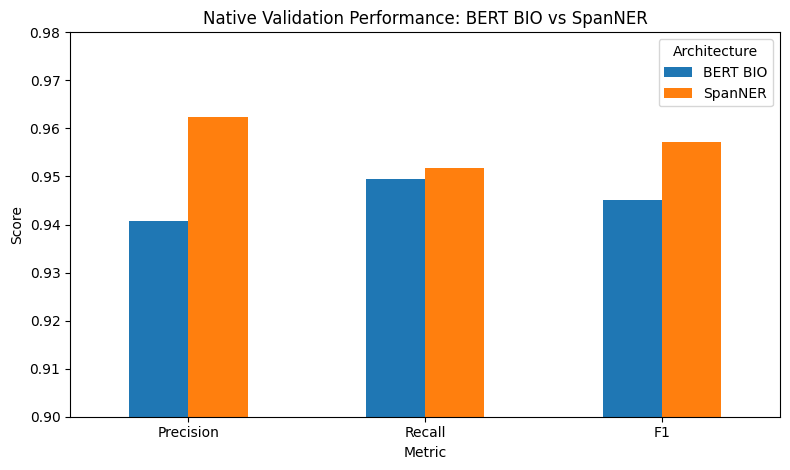

In [6]:
# Present precision, recall and F1 together because all three
# describe complementary aspects of strict typed-span performance.
plot_df = (
    native_performance_df[
        [
            "Model",
            "Precision",
            "Recall",
            "F1",
        ]
    ]
    .set_index("Model")
    .T
)

ax = plot_df.plot(
    kind="bar",
    figsize=(8, 4.8),
)

ax.set_ylim(
    0.90,
    0.98,
)

ax.set_xlabel(
    "Metric"
)

ax.set_ylabel(
    "Score"
)

ax.set_title(
    "Native Validation Performance: BERT BIO vs SpanNER"
)

ax.legend(
    title="Architecture"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

native_performance_figure_path = (
    FIGURE_OUTPUT_DIR
    / "native_validation_performance.png"
)

plt.savefig(
    native_performance_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 4. Native Boundary-Error Comparison

The two architectures are next compared according to boundary-specific prediction errors.

Start- and end-boundary correctness are defined over one-to-one matched prediction–gold pairs. An incorrect start boundary indicates that the predicted entity begins at a different word position from its matched gold entity, while an incorrect end boundary indicates disagreement at the final word position. Predictions for which either boundary is displaced contribute to the joint boundary-error count.

Unmatched false-positive predictions are not assigned artificial boundary-correctness labels and are therefore excluded from the boundary-specific denominator.

In [7]:
def summarise_boundary_errors(
    uncertainty_df,
    model_name,
):
    """Summarise boundary correctness over matched prediction–gold pairs."""

    # Saved prediction-side uncertainty tables already contain the
    # one-to-one correctness events established upstream.
    start_evaluable = uncertainty_df[
        "is_start_correct"
    ].notna()

    end_evaluable = uncertainty_df[
        "is_end_correct"
    ].notna()

    joint_evaluable = uncertainty_df[
        "is_boundary_correct"
    ].notna()

    start_errors = int(
        uncertainty_df.loc[
            start_evaluable,
            "is_start_correct",
        ]
        .eq(False)
        .sum()
    )

    end_errors = int(
        uncertainty_df.loc[
            end_evaluable,
            "is_end_correct",
        ]
        .eq(False)
        .sum()
    )

    joint_errors = int(
        uncertainty_df.loc[
            joint_evaluable,
            "is_boundary_correct",
        ]
        .eq(False)
        .sum()
    )

    return {
        "Model": model_name,
        "Matched Predictions": int(
            joint_evaluable.sum()
        ),
        "Start Errors": start_errors,
        "Start Error Rate": (
            start_errors
            / int(
                start_evaluable.sum()
            )
        ),
        "End Errors": end_errors,
        "End Error Rate": (
            end_errors
            / int(
                end_evaluable.sum()
            )
        ),
        "Any Boundary Error": (
            joint_errors
        ),
        "Any Boundary Error Rate": (
            joint_errors
            / int(
                joint_evaluable.sum()
            )
        ),
    }


native_boundary_error_df = pd.DataFrame([
    summarise_boundary_errors(
        bert_uncertainty_df,
        "BERT BIO",
    ),
    summarise_boundary_errors(
        spanner_uncertainty_df,
        "SpanNER",
    ),
])


native_boundary_error_df.to_csv(
    TABLE_OUTPUT_DIR
    / "native_boundary_error_comparison.csv",
    index=False,
)


print(
    "Native validation boundary-error comparison:"
)

display(
    native_boundary_error_df.round(6)
)

Native validation boundary-error comparison:


,Model,Matched Predictions,Start Errors,Start Error Rate,End Errors,End Error Rate,Any Boundary Error,Any Boundary Error Rate
0,BERT BIO,2981,23,0.007716,29,0.009728,50,0.016773
1,SpanNER,2953,15,0.005080,14,0.004741,28,0.009482


### 4.1 Boundary-Error Visualisation

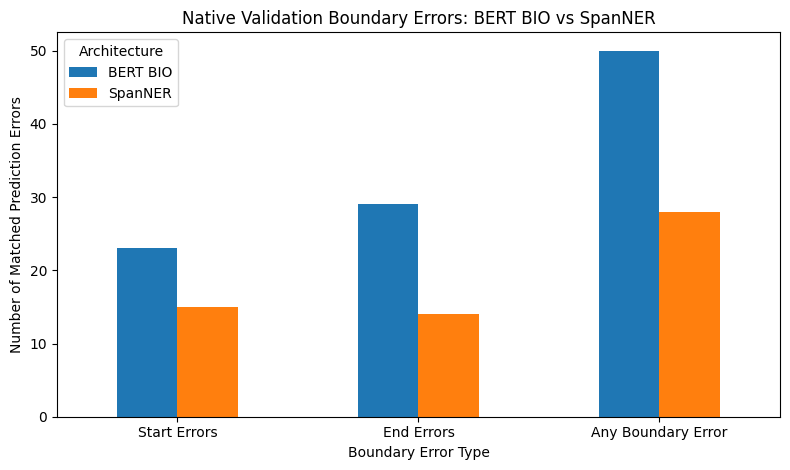

In [8]:
boundary_plot_df = (
    native_boundary_error_df[
        [
            "Model",
            "Start Errors",
            "End Errors",
            "Any Boundary Error",
        ]
    ]
    .set_index("Model")
    .T
)


ax = boundary_plot_df.plot(
    kind="bar",
    figsize=(8, 4.8),
)

ax.set_xlabel(
    "Boundary Error Type"
)

ax.set_ylabel(
    "Number of Matched Prediction Errors"
)

ax.set_title(
    "Native Validation Boundary Errors: BERT BIO vs SpanNER"
)

ax.legend(
    title="Architecture"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

boundary_error_figure_path = (
    FIGURE_OUTPUT_DIR
    / "native_boundary_error_comparison.png"
)

plt.savefig(
    boundary_error_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 5. Matched-Width Validation Comparison

The native comparison reflects each architecture's natural prediction space, but SpanNER is structurally limited to candidate spans of at most four original words. BERT BIO has no equivalent decoding-width restriction.

To separate model quality from representational support, a matched-width control is therefore performed. Gold entities and decoded predictions are restricted to spans of at most four words for both architectures, producing a shared representable evaluation condition.

This analysis does not alter or retrain either model. It provides a secondary fairness control alongside the primary native comparison.

In [9]:
MATCHED_MAX_WIDTH = 4

SPAN_IDENTITY_COLUMNS = [
    "source_index",
    "start",
    "end",
    "entity_type",
]


def restrict_to_maximum_width(
    span_df,
    maximum_width,
):
    """Restrict a span table to entities within the shared width support."""

    restricted_df = span_df.copy()

    restricted_df[
        "word_length"
    ] = (
        pd.to_numeric(
            restricted_df["end"],
            errors="raise",
        )
        - pd.to_numeric(
            restricted_df["start"],
            errors="raise",
        )
        + 1
    )

    return (
        restricted_df.loc[
            restricted_df[
                "word_length"
            ]
            <= maximum_width
        ]
        .copy()
        .reset_index(drop=True)
    )


def typed_span_identity_set(
    span_df,
):
    """Return strict typed-span identities for set-based evaluation."""

    return set(
        span_df[
            SPAN_IDENTITY_COLUMNS
        ].itertuples(
            index=False,
            name=None,
        )
    )


# Apply the same width-four support to the gold populations.
bert_gold_width4_df = (
    restrict_to_maximum_width(
        bert_gold_spans_df,
        MATCHED_MAX_WIDTH,
    )
)

spanner_gold_width4_df = (
    restrict_to_maximum_width(
        spanner_gold_spans_df,
        MATCHED_MAX_WIDTH,
    )
)

bert_gold_width4_set = (
    typed_span_identity_set(
        bert_gold_width4_df
    )
)

spanner_gold_width4_set = (
    typed_span_identity_set(
        spanner_gold_width4_df
    )
)

# This equality is scientifically necessary: both architectures
# must be evaluated against exactly the same representable gold spans.
if (
    bert_gold_width4_set
    != spanner_gold_width4_set
):
    raise RuntimeError(
        "BERT and SpanNER do not share the same width-four gold support."
    )

matched_gold_set = (
    bert_gold_width4_set
)


# Restrict each model's emitted predictions to the same span-width support.
bert_predictions_width4_df = (
    restrict_to_maximum_width(
        bert_predicted_spans_df,
        MATCHED_MAX_WIDTH,
    )
)

spanner_predictions_width4_df = (
    restrict_to_maximum_width(
        spanner_predicted_spans_df,
        MATCHED_MAX_WIDTH,
    )
)


def calculate_strict_set_metrics(
    prediction_df,
    gold_set,
    model_name,
):
    """Calculate strict typed-span metrics on the matched width support."""

    prediction_set = (
        typed_span_identity_set(
            prediction_df
        )
    )

    true_positives = len(
        prediction_set
        & gold_set
    )

    predicted_entities = len(
        prediction_set
    )

    gold_entities = len(
        gold_set
    )

    false_positives = (
        predicted_entities
        - true_positives
    )

    false_negatives = (
        gold_entities
        - true_positives
    )

    precision = (
        true_positives
        / predicted_entities
        if predicted_entities > 0
        else 0.0
    )

    recall = (
        true_positives
        / gold_entities
        if gold_entities > 0
        else 0.0
    )

    f1 = (
        2
        * precision
        * recall
        / (
            precision
            + recall
        )
        if precision + recall > 0
        else 0.0
    )

    return {
        "Model": model_name,
        "Maximum Width": (
            MATCHED_MAX_WIDTH
        ),
        "Gold Entities": (
            gold_entities
        ),
        "Predicted Entities": (
            predicted_entities
        ),
        "True Positives": (
            true_positives
        ),
        "False Positives": (
            false_positives
        ),
        "False Negatives": (
            false_negatives
        ),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
    }


matched_width_performance_df = (
    pd.DataFrame([
        calculate_strict_set_metrics(
            prediction_df=(
                bert_predictions_width4_df
            ),
            gold_set=matched_gold_set,
            model_name="BERT BIO",
        ),
        calculate_strict_set_metrics(
            prediction_df=(
                spanner_predictions_width4_df
            ),
            gold_set=matched_gold_set,
            model_name="SpanNER",
        ),
    ])
)


matched_width_performance_df.to_csv(
    TABLE_OUTPUT_DIR
    / "matched_width_validation_performance.csv",
    index=False,
)


print(
    "Matched-width strict typed-span validation performance:"
)

display(
    matched_width_performance_df.round(6)
)

Matched-width strict typed-span validation performance:


,Model,Maximum Width,Gold Entities,Predicted Entities,True Positives,False Positives,False Negatives,Precision,Recall,F1
0,BERT BIO,4,2993,3024,2846,178,147,0.941138,0.950885,0.945986
1,SpanNER,4,2993,2978,2866,112,127,0.962391,0.957568,0.959973


### 5.1 Effect of the Width-Controlled Evaluation

Native and matched-width F1 are compared to determine whether the relative performance of the two architectures changes after restricting evaluation to the span lengths representable by SpanNER.

The matched-width result is interpreted as a fairness control rather than as a replacement for native task performance.

In [10]:
native_matched_comparison_df = (
    native_performance_df[
        [
            "Model",
            "F1",
        ]
    ]
    .rename(
        columns={
            "F1": "Native F1"
        }
    )
    .merge(
        matched_width_performance_df[
            [
                "Model",
                "F1",
            ]
        ].rename(
            columns={
                "F1": (
                    "Matched Width ≤ 4 F1"
                )
            }
        ),
        on="Model",
        how="inner",
        validate="one_to_one",
    )
)


native_matched_comparison_df[
    "Width-Control Change"
] = (
    native_matched_comparison_df[
        "Matched Width ≤ 4 F1"
    ]
    - native_matched_comparison_df[
        "Native F1"
    ]
)


native_matched_comparison_df.to_csv(
    TABLE_OUTPUT_DIR
    / "native_vs_matched_width_f1.csv",
    index=False,
)


print(
    "Native and matched-width F1:"
)

display(
    native_matched_comparison_df.round(6)
)

Native and matched-width F1:


,Model,Native F1,Matched Width ≤ 4 F1,Width-Control Change
0,BERT BIO,0.945124,0.945986,0.000862
1,SpanNER,0.957088,0.959973,0.002885


## 5.2 Visualise Native and Matched-Width F1

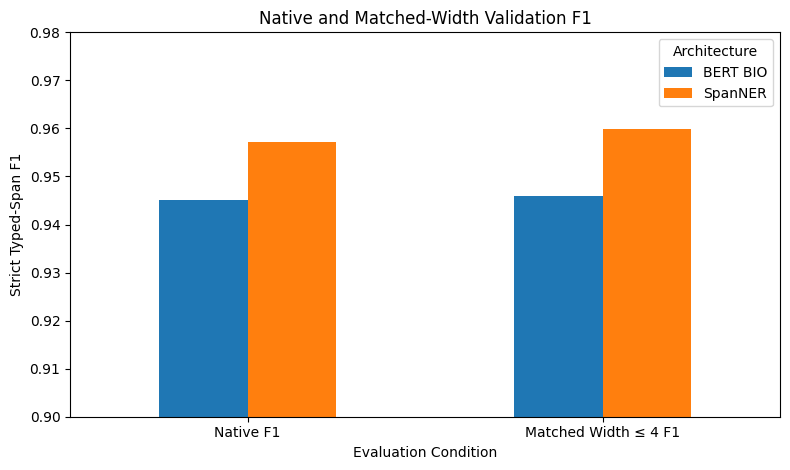

In [11]:
matched_plot_df = (
    native_matched_comparison_df[
        [
            "Model",
            "Native F1",
            "Matched Width ≤ 4 F1",
        ]
    ]
    .set_index("Model")
    .T
)


ax = matched_plot_df.plot(
    kind="bar",
    figsize=(8, 4.8),
)

ax.set_ylim(
    0.90,
    0.98,
)

ax.set_xlabel(
    "Evaluation Condition"
)

ax.set_ylabel(
    "Strict Typed-Span F1"
)

ax.set_title(
    "Native and Matched-Width Validation F1"
)

ax.legend(
    title="Architecture"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

matched_width_figure_path = (
    FIGURE_OUTPUT_DIR
    / "native_vs_matched_width_f1.png"
)

plt.savefig(
    matched_width_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 5.3 Matched-Width Boundary Errors

Boundary errors are recalculated after applying the shared width-four restriction. The prediction–gold matching is therefore repeated on the controlled populations rather than obtained by filtering the native matching results.

The same deterministic one-to-one matching procedure is applied to both architectures. Exact typed-span matches are assigned first, followed by identical-boundary matches and then remaining overlapping spans. For overlapping alternatives, matching prioritises the same entity type, greater token overlap, higher intersection-over-union and smaller boundary displacement.

A prediction with both boundaries displaced contributes to both the total start-error and total end-error counts.

In [12]:
def calculate_overlap_features(prediction, gold):
    """Calculate overlap quantities for one prediction–gold pair."""

    predicted_start = int(
        prediction["start"]
    )
    predicted_end = int(
        prediction["end"]
    )

    gold_start = int(
        gold["start"]
    )
    gold_end = int(
        gold["end"]
    )

    overlap_tokens = max(
        0,
        min(
            predicted_end,
            gold_end,
        )
        - max(
            predicted_start,
            gold_start,
        )
        + 1,
    )

    predicted_length = (
        predicted_end
        - predicted_start
        + 1
    )

    gold_length = (
        gold_end
        - gold_start
        + 1
    )

    union_tokens = (
        predicted_length
        + gold_length
        - overlap_tokens
    )

    overlap_iou = (
        overlap_tokens
        / union_tokens
        if union_tokens > 0
        else 0.0
    )

    boundary_distance = (
        abs(
            predicted_start
            - gold_start
        )
        + abs(
            predicted_end
            - gold_end
        )
    )

    return {
        "overlap_tokens": int(
            overlap_tokens
        ),
        "overlap_iou": float(
            overlap_iou
        ),
        "boundary_distance": int(
            boundary_distance
        ),
    }


def determine_boundary_error_category(
    prediction,
    gold,
):
    """Assign the mutually exclusive diagnostic category for a matched pair."""

    start_correct = (
        int(
            prediction["start"]
        )
        == int(
            gold["start"]
        )
    )

    end_correct = (
        int(
            prediction["end"]
        )
        == int(
            gold["end"]
        )
    )

    type_correct = (
        str(
            prediction[
                "entity_type"
            ]
        )
        == str(
            gold[
                "entity_type"
            ]
        )
    )

    if (
        start_correct
        and end_correct
        and type_correct
    ):
        return "exact_match"

    if (
        start_correct
        and end_correct
    ):
        return "type_error"

    if (
        not start_correct
        and end_correct
    ):
        return "start_boundary_error"

    if (
        start_correct
        and not end_correct
    ):
        return "end_boundary_error"

    return "both_boundary_error"


def match_sentence_for_boundary_analysis(
    predicted_spans,
    gold_spans,
):
    """Create deterministic one-to-one prediction–gold matches."""

    predictions = [
        dict(span)
        for span in predicted_spans
    ]

    gold = [
        dict(span)
        for span in gold_spans
    ]

    unmatched_predictions = set(
        range(
            len(predictions)
        )
    )

    unmatched_gold = set(
        range(
            len(gold)
        )
    )

    matched_pairs = []

    # Stage 1: prioritise exact typed-span matches.
    for prediction_index in sorted(
        unmatched_predictions.copy()
    ):
        prediction = predictions[
            prediction_index
        ]

        candidates = [
            gold_index
            for gold_index in sorted(
                unmatched_gold
            )
            if (
                prediction["start"]
                == gold[
                    gold_index
                ]["start"]
                and prediction["end"]
                == gold[
                    gold_index
                ]["end"]
                and prediction[
                    "entity_type"
                ]
                == gold[
                    gold_index
                ]["entity_type"]
            )
        ]

        if candidates:
            gold_index = candidates[0]

            matched_pairs.append(
                (
                    prediction_index,
                    gold_index,
                )
            )

            unmatched_predictions.remove(
                prediction_index
            )

            unmatched_gold.remove(
                gold_index
            )

    # Stage 2: match identical boundaries even when the type differs.
    for prediction_index in sorted(
        unmatched_predictions.copy()
    ):
        prediction = predictions[
            prediction_index
        ]

        candidates = [
            gold_index
            for gold_index in sorted(
                unmatched_gold
            )
            if (
                prediction["start"]
                == gold[
                    gold_index
                ]["start"]
                and prediction["end"]
                == gold[
                    gold_index
                ]["end"]
            )
        ]

        if candidates:
            gold_index = candidates[0]

            matched_pairs.append(
                (
                    prediction_index,
                    gold_index,
                )
            )

            unmatched_predictions.remove(
                prediction_index
            )

            unmatched_gold.remove(
                gold_index
            )

    # Stage 3: construct all remaining overlapping alternatives.
    overlap_candidates = []

    for prediction_index in (
        unmatched_predictions
    ):
        prediction = predictions[
            prediction_index
        ]

        for gold_index in (
            unmatched_gold
        ):
            gold_span = gold[
                gold_index
            ]

            overlap_features = (
                calculate_overlap_features(
                    prediction,
                    gold_span,
                )
            )

            if (
                overlap_features[
                    "overlap_tokens"
                ]
                == 0
            ):
                continue

            overlap_candidates.append({
                "prediction_index":
                    prediction_index,
                "gold_index":
                    gold_index,
                "type_match": (
                    prediction[
                        "entity_type"
                    ]
                    == gold_span[
                        "entity_type"
                    ]
                ),
                **overlap_features,
            })

    # Preserve the validated deterministic matching priority.
    overlap_candidates.sort(
        key=lambda row: (
            -int(
                row[
                    "type_match"
                ]
            ),
            -row[
                "overlap_tokens"
            ],
            -row[
                "overlap_iou"
            ],
            row[
                "boundary_distance"
            ],
            row[
                "prediction_index"
            ],
            row[
                "gold_index"
            ],
        )
    )

    for candidate in (
        overlap_candidates
    ):
        prediction_index = candidate[
            "prediction_index"
        ]

        gold_index = candidate[
            "gold_index"
        ]

        if (
            prediction_index
            not in unmatched_predictions
            or gold_index
            not in unmatched_gold
        ):
            continue

        matched_pairs.append(
            (
                prediction_index,
                gold_index,
            )
        )

        unmatched_predictions.remove(
            prediction_index
        )

        unmatched_gold.remove(
            gold_index
        )

    error_categories = []

    for (
        prediction_index,
        gold_index,
    ) in matched_pairs:
        error_categories.append(
            determine_boundary_error_category(
                predictions[
                    prediction_index
                ],
                gold[
                    gold_index
                ],
            )
        )

    error_categories.extend(
        [
            "false_positive"
            for _ in
            unmatched_predictions
        ]
    )

    error_categories.extend(
        [
            "false_negative"
            for _ in
            unmatched_gold
        ]
    )

    return error_categories


def run_matched_width_boundary_analysis(
    predicted_df,
    gold_df,
):
    """Apply boundary matching independently within each validation sentence."""

    categories = []

    sentence_indices = sorted(
        set(
            predicted_df[
                "source_index"
            ].astype(int)
        )
        | set(
            gold_df[
                "source_index"
            ].astype(int)
        )
    )

    for source_index in (
        sentence_indices
    ):
        sentence_predictions = (
            predicted_df.loc[
                predicted_df[
                    "source_index"
                ].eq(
                    source_index
                ),
                [
                    "start",
                    "end",
                    "entity_type",
                ],
            ]
            .to_dict(
                "records"
            )
        )

        sentence_gold = (
            gold_df.loc[
                gold_df[
                    "source_index"
                ].eq(
                    source_index
                ),
                [
                    "start",
                    "end",
                    "entity_type",
                ],
            ]
            .to_dict(
                "records"
            )
        )

        categories.extend(
            match_sentence_for_boundary_analysis(
                sentence_predictions,
                sentence_gold,
            )
        )

    return pd.Series(
        categories,
        name="error_category",
    )


print(
    "Matched-width boundary matcher configured."
)

Matched-width boundary matcher configured.


### Calculate matched-width boundary errors

In [13]:
bert_width4_error_categories = (
    run_matched_width_boundary_analysis(
        bert_predictions_width4_df,
        bert_gold_width4_df,
    )
)

spanner_width4_error_categories = (
    run_matched_width_boundary_analysis(
        spanner_predictions_width4_df,
        spanner_gold_width4_df,
    )
)


def summarise_matched_boundary_errors(
    error_categories,
    model_name,
):
    """Summarise matched-width boundary-error categories."""

    counts = (
        error_categories
        .value_counts()
        .to_dict()
    )

    start_only = int(
        counts.get(
            "start_boundary_error",
            0,
        )
    )

    end_only = int(
        counts.get(
            "end_boundary_error",
            0,
        )
    )

    both = int(
        counts.get(
            "both_boundary_error",
            0,
        )
    )

    return {
        "Model": model_name,
        "Exact Matches": int(
            counts.get(
                "exact_match",
                0,
            )
        ),
        "Start-only Errors": (
            start_only
        ),
        "End-only Errors": (
            end_only
        ),
        "Both-Boundary Errors": (
            both
        ),
        "Total Start Errors": (
            start_only
            + both
        ),
        "Total End Errors": (
            end_only
            + both
        ),
        "Any Boundary Error": (
            start_only
            + end_only
            + both
        ),
        "Type Errors": int(
            counts.get(
                "type_error",
                0,
            )
        ),
        "False Positives": int(
            counts.get(
                "false_positive",
                0,
            )
        ),
        "False Negatives": int(
            counts.get(
                "false_negative",
                0,
            )
        ),
    }


matched_width_boundary_df = (
    pd.DataFrame([
        summarise_matched_boundary_errors(
            bert_width4_error_categories,
            "BERT BIO",
        ),
        summarise_matched_boundary_errors(
            spanner_width4_error_categories,
            "SpanNER",
        ),
    ])
)


matched_width_boundary_df.to_csv(
    TABLE_OUTPUT_DIR
    / "matched_width_boundary_errors.csv",
    index=False,
)


print(
    "Matched-width validation boundary errors:"
)

display(
    matched_width_boundary_df
)

Matched-width validation boundary errors:


,Model,Exact Matches,Start-only Errors,End-only Errors,Both-Boundary Errors,Total Start Errors,Total End Errors,Any Boundary Error,Type Errors,False Positives,False Negatives
0,BERT BIO,2846,19,24,1,20,25,44,72,62,31
1,SpanNER,2866,12,11,1,13,12,24,59,29,44


### 5.4 Architecture Comparison Summary

The native and width-controlled results are reported together to distinguish end-to-end system performance from the controlled comparison over shared representational support.

In [14]:
final_architecture_summary_df = pd.DataFrame([
    {
        "Model": "BERT BIO",
        "Condition": "Native",
        "Gold Entities": int(
            bert_native_row[
                "Gold Entities"
            ]
        ),
        "Precision": float(
            bert_native_row[
                "Precision"
            ]
        ),
        "Recall": float(
            bert_native_row[
                "Recall"
            ]
        ),
        "F1": float(
            bert_native_row[
                "F1"
            ]
        ),
        "Start Errors": int(
            native_boundary_error_df.loc[
                native_boundary_error_df[
                    "Model"
                ].eq(
                    "BERT BIO"
                ),
                "Start Errors",
            ].iloc[0]
        ),
        "End Errors": int(
            native_boundary_error_df.loc[
                native_boundary_error_df[
                    "Model"
                ].eq(
                    "BERT BIO"
                ),
                "End Errors",
            ].iloc[0]
        ),
    },
    {
        "Model": "SpanNER",
        "Condition": "Native",
        "Gold Entities": int(
            spanner_native_row[
                "Gold Entities"
            ]
        ),
        "Precision": float(
            spanner_native_row[
                "Precision"
            ]
        ),
        "Recall": float(
            spanner_native_row[
                "Recall"
            ]
        ),
        "F1": float(
            spanner_native_row[
                "F1"
            ]
        ),
        "Start Errors": int(
            native_boundary_error_df.loc[
                native_boundary_error_df[
                    "Model"
                ].eq(
                    "SpanNER"
                ),
                "Start Errors",
            ].iloc[0]
        ),
        "End Errors": int(
            native_boundary_error_df.loc[
                native_boundary_error_df[
                    "Model"
                ].eq(
                    "SpanNER"
                ),
                "End Errors",
            ].iloc[0]
        ),
    },
])


for model_name in [
    "BERT BIO",
    "SpanNER",
]:
    metric_row = (
        matched_width_performance_df.loc[
            matched_width_performance_df[
                "Model"
            ].eq(
                model_name
            )
        ]
        .iloc[0]
    )

    boundary_row = (
        matched_width_boundary_df.loc[
            matched_width_boundary_df[
                "Model"
            ].eq(
                model_name
            )
        ]
        .iloc[0]
    )

    final_architecture_summary_df.loc[
        len(
            final_architecture_summary_df
        )
    ] = {
        "Model": model_name,
        "Condition": (
            "Matched width ≤ 4"
        ),
        "Gold Entities": int(
            metric_row[
                "Gold Entities"
            ]
        ),
        "Precision": float(
            metric_row[
                "Precision"
            ]
        ),
        "Recall": float(
            metric_row[
                "Recall"
            ]
        ),
        "F1": float(
            metric_row[
                "F1"
            ]
        ),
        "Start Errors": int(
            boundary_row[
                "Total Start Errors"
            ]
        ),
        "End Errors": int(
            boundary_row[
                "Total End Errors"
            ]
        ),
    }


final_architecture_summary_df.to_csv(
    TABLE_OUTPUT_DIR
    / "final_architecture_validation_summary.csv",
    index=False,
)


print(
    "Final native and width-controlled architecture comparison:"
)

display(
    final_architecture_summary_df.round(
        6
    )
)

Final native and width-controlled architecture comparison:


,Model,Condition,Gold Entities,Precision,Recall,F1,Start Errors,End Errors
0,BERT BIO,Native,3011,0.940770,0.949518,0.945124,23,29
1,SpanNER,Native,3011,0.962391,0.951843,0.957088,15,14
2,BERT BIO,Matched width ≤ 4,2993,0.941138,0.950885,0.945986,20,25
3,SpanNER,Matched width ≤ 4,2993,0.962391,0.957568,0.959973,13,12


## 6. Standardise Architecture-Specific Uncertainty Signals

BERT BIO and SpanNER produce uncertainty from different prediction structures. BERT derives entity confidence from token-level BIO probabilities, whereas SpanNER assigns probabilities directly to candidate spans. Their raw uncertainty values are therefore not interpreted as directly comparable quantities.

For formal evaluation, both architectures are placed into a common analysis framework. Prediction identities and correctness events are standardised, and every uncertainty score is oriented so that larger values indicate greater uncertainty.

Four prediction events are considered:

- incorrect typed span;
- incorrect start boundary;
- incorrect end boundary;
- any incorrect boundary.

Typed-span correctness is defined for every emitted prediction. Boundary correctness remains undefined for unmatched false-positive predictions because no matched gold boundary exists.

Entropy-based MC-Dropout quantities are normalised by the maximum entropy of the corresponding output space where required: log(9) for BERT BIO and log(5) for SpanNER. This normalisation affects scale but not within-model ranking.

In [15]:
def parse_nullable_boolean(series):
    """Convert CSV boolean representations while preserving missing values."""

    mapping = {
        True: True,
        False: False,
        "True": True,
        "False": False,
        "true": True,
        "false": False,
        1: True,
        0: False,
        "1": True,
        "0": False,
        "": pd.NA,
        None: pd.NA,
    }

    converted = series.map(
        mapping
    )

    original_missing = (
        series.isna()
        | series.astype(str).eq("")
    )

    unparsed = (
        converted.isna()
        & ~original_missing
    )

    if unparsed.any():
        unexpected = (
            series.loc[
                unparsed
            ]
            .astype(str)
            .unique()
            .tolist()
        )

        raise ValueError(
            "Unexpected boolean value(s): "
            f"{unexpected}"
        )

    return converted.astype(
        "boolean"
    )


def add_common_error_events(
    dataframe,
):
    """Create common error indicators from correctness labels."""

    result = dataframe.copy()

    for column_name in [
        "is_exact_correct",
        "is_start_correct",
        "is_end_correct",
        "is_boundary_correct",
    ]:
        result[column_name] = (
            parse_nullable_boolean(
                result[
                    column_name
                ]
            )
        )

    # Whole-span correctness exists for every emitted prediction.
    result[
        "event_span_error"
    ] = (
        ~result[
            "is_exact_correct"
        ]
    ).astype(
        "boolean"
    )

    # Boundary events remain undefined where no gold span
    # was assigned to the emitted prediction.
    for correctness_column, event_column in [
        (
            "is_start_correct",
            "event_start_error",
        ),
        (
            "is_end_correct",
            "event_end_error",
        ),
        (
            "is_boundary_correct",
            "event_joint_boundary_error",
        ),
    ]:
        result[
            event_column
        ] = pd.Series(
            pd.NA,
            index=result.index,
            dtype="boolean",
        )

        evaluable = result[
            correctness_column
        ].notna()

        result.loc[
            evaluable,
            event_column,
        ] = (
            ~result.loc[
                evaluable,
                correctness_column,
            ]
        )

    return result


print(
    "Common uncertainty-event schema configured."
)

Common uncertainty-event schema configured.


## 6.2 Standardise BERT and SpanNER Validation Tables

In [16]:
# Begin from the frozen prediction-side uncertainty outputs generated
# independently by the two architecture notebooks.
bert_df = add_common_error_events(
    bert_uncertainty_df
)

spanner_df = add_common_error_events(
    spanner_uncertainty_df
)


# Standardise prediction identity without changing either model's
# underlying emitted prediction population.
for column_name in [
    "source_index",
    "sentence_index",
    "predicted_start",
    "predicted_end",
]:
    bert_df[column_name] = pd.to_numeric(
        bert_df[column_name],
        errors="raise",
    ).astype(int)

bert_df[
    "pred_start"
] = bert_df[
    "predicted_start"
]

bert_df[
    "pred_end"
] = bert_df[
    "predicted_end"
]

bert_df[
    "pred_type"
] = bert_df[
    "predicted_entity_type"
].astype(str)


for column_name in [
    "source_index",
    "sentence_index",
    "start",
    "end",
]:
    spanner_df[column_name] = pd.to_numeric(
        spanner_df[column_name],
        errors="raise",
    ).astype(int)

spanner_df[
    "pred_start"
] = spanner_df[
    "start"
]

spanner_df[
    "pred_end"
] = spanner_df[
    "end"
]

spanner_df[
    "pred_type"
] = spanner_df[
    "entity_type"
].astype(str)


# BERT uses nine BIO output classes. Normalised MC entropy and mutual
# information features are derived only when the upstream file contains
# their raw equivalents rather than the already-normalised versions.
BERT_ENTROPY_NORMALISER = float(
    np.log(9)
)

bert_normalisation_pairs = {
    "mc_span_mean_normalised_predictive_entropy":
        "mc_span_mean_predictive_entropy",

    "mc_span_max_normalised_predictive_entropy":
        "mc_span_max_predictive_entropy",

    "mc_span_mean_normalised_mutual_information":
        "mc_span_mean_mutual_information",

    "mc_span_max_normalised_mutual_information":
        "mc_span_max_mutual_information",

    "mc_start_normalised_mutual_information":
        "mc_start_mutual_information",

    "mc_end_normalised_mutual_information":
        "mc_end_mutual_information",
}


for normalised_column, raw_column in (
    bert_normalisation_pairs.items()
):
    if (
        normalised_column
        not in bert_df.columns
        and raw_column
        in bert_df.columns
    ):
        bert_df[
            normalised_column
        ] = (
            pd.to_numeric(
                bert_df[
                    raw_column
                ],
                errors="coerce",
            )
            / BERT_ENTROPY_NORMALISER
        )


# Joint endpoint disagreement uses the more uncertain endpoint.
if all(
    column in bert_df.columns
    for column in [
        "mc_start_normalised_mutual_information",
        "mc_end_normalised_mutual_information",
    ]
):
    bert_df[
        "mc_joint_endpoint_normalised_mutual_information"
    ] = bert_df[
        [
            "mc_start_normalised_mutual_information",
            "mc_end_normalised_mutual_information",
        ]
    ].max(
        axis=1,
        skipna=True,
    )


# Convert fixed-class MC probabilities into uncertainty orientation.
if (
    "mc_start_fixed_class_mean_probability"
    in bert_df.columns
):
    bert_df[
        "mc_start_fixed_class_uncertainty"
    ] = (
        1.0
        - pd.to_numeric(
            bert_df[
                "mc_start_fixed_class_mean_probability"
            ],
            errors="coerce",
        )
    )

if (
    "mc_end_fixed_class_mean_probability"
    in bert_df.columns
):
    bert_df[
        "mc_end_fixed_class_uncertainty"
    ] = (
        1.0
        - pd.to_numeric(
            bert_df[
                "mc_end_fixed_class_mean_probability"
            ],
            errors="coerce",
        )
    )


# SpanNER's entropy-based features were normalised by log(5)
# in Notebook 02. Only the fixed-label probability is converted
# here into uncertainty orientation.
if (
    "mc_span_fixed_label_mean_probability"
    in spanner_df.columns
):
    spanner_df[
        "mc_span_fixed_label_uncertainty"
    ] = (
        1.0
        - pd.to_numeric(
            spanner_df[
                "mc_span_fixed_label_mean_probability"
            ],
            errors="coerce",
        )
    )


print(
    "BERT and SpanNER validation uncertainty tables standardised."
)

BERT and SpanNER validation uncertainty tables standardised.


## 6.3 Error Populations Used by Formal Evaluation

In [17]:
def summarise_uncertainty_events(
    dataframe,
    model_name,
):
    """Summarise prediction and boundary-event populations."""

    return {
        "Model": model_name,

        "Predictions": int(
            len(dataframe)
        ),

        "Span Errors": int(
            dataframe[
                "event_span_error"
            ]
            .eq(True)
            .sum()
        ),

        "Start Evaluable": int(
            dataframe[
                "event_start_error"
            ]
            .notna()
            .sum()
        ),

        "Start Errors": int(
            dataframe[
                "event_start_error"
            ]
            .eq(True)
            .sum()
        ),

        "End Evaluable": int(
            dataframe[
                "event_end_error"
            ]
            .notna()
            .sum()
        ),

        "End Errors": int(
            dataframe[
                "event_end_error"
            ]
            .eq(True)
            .sum()
        ),

        "Joint Evaluable": int(
            dataframe[
                "event_joint_boundary_error"
            ]
            .notna()
            .sum()
        ),

        "Joint Boundary Errors": int(
            dataframe[
                "event_joint_boundary_error"
            ]
            .eq(True)
            .sum()
        ),
    }


uncertainty_event_summary_df = pd.DataFrame([
    summarise_uncertainty_events(
        bert_df,
        "BERT BIO",
    ),
    summarise_uncertainty_events(
        spanner_df,
        "SpanNER",
    ),
])


uncertainty_event_summary_df.to_csv(
    TABLE_OUTPUT_DIR
    / "uncertainty_event_populations.csv",
    index=False,
)


print(
    "Validation populations for formal uncertainty evaluation:"
)

display(
    uncertainty_event_summary_df
)

Validation populations for formal uncertainty evaluation:


,Model,Predictions,Span Errors,Start Evaluable,Start Errors,End Evaluable,End Errors,Joint Evaluable,Joint Boundary Errors
0,BERT BIO,3039,180,2981,23,2981,29,2981,50
1,SpanNER,2978,112,2953,15,2953,14,2953,28


### 6.4 Predefined Uncertainty Signals

The formal uncertainty signals are declared before discrimination metrics are calculated.

Primary signals represent the architecture-native quantities central to the dissertation methodology. Secondary deterministic, endpoint and MC-Dropout measures are retained to determine whether simpler or more generic uncertainty measures provide comparable or stronger error ranking.

The registry therefore separates a signal's methodological role from its eventual observed AUROC or AUPRC.

In [18]:
signal_records = []


def register_signal(
    model,
    dataframe,
    event,
    signal,
    display_name,
    family,
    role,
    primary=False,
    required=False,
):
    """Register one uncertainty signal for formal evaluation."""

    if signal not in dataframe.columns:
        if required:
            raise KeyError(
                f"Required {model} uncertainty signal is missing: "
                f"{signal}"
            )

        # Optional secondary signals are omitted when they were not
        # persisted by the final upstream architecture notebook.
        return

    signal_records.append({
        "Model": model,
        "Event": event,
        "Signal": signal,
        "Display Name": display_name,
        "Source Family": family,
        "Signal Role": role,
        "Primary": bool(
            primary
        ),
    })


# Overall BERT uncertainty.
bert_span_signals = [
    (
        "det_span_geometric_uncertainty",
        "Geometric BIO span",
        "Deterministic",
        "Architecture-native span",
        True,
        True,
    ),
    (
        "det_span_mean_margin_uncertainty",
        "Mean token margin",
        "Deterministic",
        "Generic span",
        False,
        True,
    ),
    (
        "det_span_normalised_max_entropy_uncertainty",
        "Maximum token entropy",
        "Deterministic",
        "Generic span",
        False,
        False,
    ),
    (
        "mc_span_geometric_fixed_label_uncertainty",
        "MC geometric fixed-label",
        "MC dropout",
        "Generic span",
        False,
        True,
    ),
    (
        "mc_span_mean_normalised_predictive_entropy",
        "MC mean predictive entropy",
        "MC dropout",
        "Generic span",
        False,
        True,
    ),
    (
        "mc_span_mean_normalised_mutual_information",
        "MC mean mutual information",
        "MC dropout",
        "Generic span",
        True,
        True,
    ),
    (
        "mc_span_mean_fixed_class_variance",
        "MC mean class variance",
        "MC dropout",
        "Generic span",
        False,
        True,
    ),
    (
        "mc_span_mean_variation_ratio",
        "MC mean variation ratio",
        "MC dropout",
        "Generic span",
        False,
        True,
    ),
]

for specification in bert_span_signals:
    register_signal(
        "BERT",
        bert_df,
        "span",
        *specification,
    )


# Overall SpanNER uncertainty.
spanner_span_signals = [
    (
        "det_span_probability_uncertainty",
        "Direct span probability",
        "Deterministic",
        "Architecture-native span",
        True,
        True,
    ),
    (
        "det_span_normalised_entropy_uncertainty",
        "Five-class entropy",
        "Deterministic",
        "Generic span",
        False,
        True,
    ),
    (
        "det_span_margin_uncertainty",
        "Five-class probability margin",
        "Deterministic",
        "Generic span",
        False,
        True,
    ),
    (
        "mc_span_fixed_label_uncertainty",
        "MC fixed-label probability",
        "MC dropout",
        "Generic span",
        False,
        True,
    ),
    (
        "mc_span_normalised_predictive_entropy",
        "MC predictive entropy",
        "MC dropout",
        "Generic span",
        False,
        True,
    ),
    (
        "mc_span_normalised_mutual_information",
        "MC mutual information",
        "MC dropout",
        "Generic span",
        True,
        True,
    ),
    (
        "mc_span_fixed_label_probability_variance",
        "MC class variance",
        "MC dropout",
        "Generic span",
        False,
        True,
    ),
    (
        "mc_span_variation_ratio",
        "MC variation ratio",
        "MC dropout",
        "Generic span",
        False,
        True,
    ),
]

for specification in spanner_span_signals:
    register_signal(
        "SpanNER",
        spanner_df,
        "span",
        *specification,
    )


# Architecture-native BERT boundary signals.
bert_boundary_signals = {
    "start": [
        (
            "det_start_bio_boundary_uncertainty",
            "BIO start ambiguity",
            "Deterministic",
            "Architecture-native boundary",
            True,
            True,
        ),
        (
            "mc_start_bio_boundary_uncertainty",
            "MC BIO start ambiguity",
            "MC dropout",
            "Architecture-native boundary",
            True,
            True,
        ),
        (
            "mc_start_normalised_mutual_information",
            "MC start-token mutual information",
            "MC dropout",
            "Endpoint",
            False,
            True,
        ),
        (
            "det_span_geometric_uncertainty",
            "Geometric BIO span",
            "Deterministic",
            "Generic span",
            False,
            True,
        ),
    ],

    "end": [
        (
            "det_end_bio_continuation_uncertainty",
            "BIO right-continuation ambiguity",
            "Deterministic",
            "Architecture-native boundary",
            True,
            True,
        ),
        (
            "mc_end_bio_continuation_uncertainty",
            "MC BIO right-continuation ambiguity",
            "MC dropout",
            "Architecture-native boundary",
            True,
            True,
        ),
        (
            "mc_end_normalised_mutual_information",
            "MC end-token mutual information",
            "MC dropout",
            "Endpoint",
            False,
            True,
        ),
        (
            "det_span_geometric_uncertainty",
            "Geometric BIO span",
            "Deterministic",
            "Generic span",
            False,
            True,
        ),
    ],

    "joint": [
        (
            "det_joint_bio_boundary_uncertainty",
            "Joint BIO boundary ambiguity",
            "Deterministic",
            "Architecture-native boundary",
            True,
            True,
        ),
        (
            "mc_joint_bio_boundary_uncertainty",
            "MC joint BIO boundary ambiguity",
            "MC dropout",
            "Architecture-native boundary",
            True,
            True,
        ),
        (
            "mc_joint_endpoint_normalised_mutual_information",
            "MC maximum endpoint mutual information",
            "MC dropout",
            "Endpoint",
            False,
            True,
        ),
        (
            "det_span_geometric_uncertainty",
            "Geometric BIO span",
            "Deterministic",
            "Generic span",
            False,
            True,
        ),
    ],
}


for event, specifications in (
    bert_boundary_signals.items()
):
    for specification in specifications:
        register_signal(
            "BERT",
            bert_df,
            event,
            *specification,
        )


# Architecture-native SpanNER boundary signals.
spanner_boundary_signals = {
    "start": [
        (
            "det_start_boundary_competition_uncertainty",
            "Start boundary competition",
            "Deterministic",
            "Architecture-native boundary",
            True,
            True,
        ),
        (
            "mc_start_boundary_competition_uncertainty",
            "MC start boundary competition",
            "MC dropout",
            "Architecture-native boundary",
            True,
            True,
        ),
        (
            "det_span_probability_uncertainty",
            "Direct span probability",
            "Deterministic",
            "Generic span",
            False,
            True,
        ),
        (
            "mc_span_normalised_mutual_information",
            "MC span mutual information",
            "MC dropout",
            "Generic span",
            False,
            True,
        ),
    ],

    "end": [
        (
            "det_end_boundary_competition_uncertainty",
            "End boundary competition",
            "Deterministic",
            "Architecture-native boundary",
            True,
            True,
        ),
        (
            "mc_end_boundary_competition_uncertainty",
            "MC end boundary competition",
            "MC dropout",
            "Architecture-native boundary",
            True,
            True,
        ),
        (
            "det_span_probability_uncertainty",
            "Direct span probability",
            "Deterministic",
            "Generic span",
            False,
            True,
        ),
        (
            "mc_span_normalised_mutual_information",
            "MC span mutual information",
            "MC dropout",
            "Generic span",
            False,
            True,
        ),
    ],

    "joint": [
        (
            "det_joint_boundary_competition_uncertainty",
            "Joint boundary competition",
            "Deterministic",
            "Architecture-native boundary",
            True,
            True,
        ),
        (
            "mc_joint_boundary_competition_uncertainty",
            "MC joint boundary competition",
            "MC dropout",
            "Architecture-native boundary",
            True,
            True,
        ),
        (
            "det_span_probability_uncertainty",
            "Direct span probability",
            "Deterministic",
            "Generic span",
            False,
            True,
        ),
        (
            "mc_span_normalised_mutual_information",
            "MC span mutual information",
            "MC dropout",
            "Generic span",
            False,
            True,
        ),
    ],
}


for event, specifications in (
    spanner_boundary_signals.items()
):
    for specification in specifications:
        register_signal(
            "SpanNER",
            spanner_df,
            event,
            *specification,
        )


signal_registry_df = pd.DataFrame(
    signal_records
)

signal_registry_df.to_csv(
    CONFIG_OUTPUT_DIR
    / "uncertainty_signal_registry.csv",
    index=False,
)


# Only the predefined primary signals are displayed in the final
# notebook; the complete registry remains saved for reproducibility.
primary_signal_registry_df = (
    signal_registry_df.loc[
        signal_registry_df[
            "Primary"
        ]
    ]
    .reset_index(
        drop=True
    )
)


print(
    "Predefined primary uncertainty signals:"
)

display(
    primary_signal_registry_df
)

Predefined primary uncertainty signals:


,Model,Event,Signal,Display Name,Source Family,Signal Role,Primary
0,BERT,span,det_span_geometric_uncertainty,Geometric BIO span,Deterministic,Architecture-native span,True
1,BERT,span,mc_span_mean_normalised_mutual_information,MC mean mutual information,MC dropout,Generic span,True
2,SpanNER,span,det_span_probability_uncertainty,Direct span probability,Deterministic,Architecture-native span,True
3,SpanNER,span,mc_span_normalised_mutual_information,MC mutual information,MC dropout,Generic span,True
4,BERT,start,det_start_bio_boundary_uncertainty,BIO start ambiguity,Deterministic,Architecture-native boundary,True
5,BERT,start,mc_start_bio_boundary_uncertainty,MC BIO start ambiguity,MC dropout,Architecture-native boundary,True
6,BERT,end,det_end_bio_continuation_uncertainty,BIO right-continuation ambiguity,Deterministic,Architecture-native boundary,True
7,BERT,end,mc_end_bio_continuation_uncertainty,MC BIO right-continuation ambiguity,MC dropout,Architecture-native boundary,True
8,BERT,joint,det_joint_bio_boundary_uncertainty,Joint BIO boundary ambiguity,Deterministic,Architecture-native boundary,True
9,BERT,joint,mc_joint_bio_boundary_uncertainty,MC joint BIO boundary ambiguity,MC dropout,Architecture-native boundary,True


## 7. Formal Error-Discrimination Analysis

The registered uncertainty signals are evaluated according to their ability to rank erroneous predictions above correct predictions.

Error is treated as the positive class and larger uncertainty values indicate greater predicted risk. AUROC measures ranking discrimination across all decision thresholds, while AUPRC focuses on retrieval of the comparatively rare error cases.

Because AUPRC depends strongly on positive-class prevalence, each result is reported alongside the error prevalence within the score-specific evaluable population. AUPRC lift over random ranking is calculated as the ratio between observed AUPRC and this prevalence baseline.

Uncertainty values may be unavailable for some predictions, particularly SpanNER boundary-competition signals when no valid same-type alternative boundary exists. Each score is therefore evaluated only on rows for which both the corresponding error label and uncertainty value are available.

Uncertainty intervals are estimated using 500 sentence-cluster bootstrap replicates. Entire validation sentences are resampled with replacement so that multiple predictions originating from the same sentence remain grouped.

In [19]:
BOOTSTRAP_REPLICATES = 500
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95


EVENT_TARGET_COLUMNS = {
    "span": "event_span_error",
    "start": "event_start_error",
    "end": "event_end_error",
    "joint": "event_joint_boundary_error",
}

EVENT_DISPLAY_NAMES = {
    "span": "Incorrect typed span",
    "start": "Incorrect start boundary",
    "end": "Incorrect end boundary",
    "joint": "Any incorrect boundary",
}

MODEL_DATAFRAMES = {
    "BERT": bert_df,
    "SpanNER": spanner_df,
}


def cluster_bootstrap_metric_interval(
    dataframe,
    target_column,
    score_column,
    bootstrap_replicates,
    seed,
):
    """
    Estimate AUROC and AUPRC intervals by resampling complete
    validation sentences rather than individual predictions.
    """

    analysis_df = dataframe[
        [
            "sentence_index",
            target_column,
            score_column,
        ]
    ].copy()

    analysis_df[
        target_column
    ] = analysis_df[
        target_column
    ].astype(
        "boolean"
    )

    analysis_df[
        score_column
    ] = pd.to_numeric(
        analysis_df[
            score_column
        ],
        errors="coerce",
    )

    # Only predictions with both an evaluable event label and
    # an available uncertainty score enter this score-specific analysis.
    analysis_df = (
        analysis_df
        .dropna(
            subset=[
                target_column,
                score_column,
            ]
        )
        .reset_index(
            drop=True
        )
    )

    analysis_df[
        target_column
    ] = (
        analysis_df[
            target_column
        ]
        .astype(bool)
        .astype(int)
    )

    # Preserve the natural sentence-level dependence structure.
    sentence_row_indices = {
        sentence_index: group.index.to_numpy()
        for sentence_index, group
        in analysis_df.groupby(
            "sentence_index",
            sort=False,
        )
    }

    sentence_ids = np.asarray(
        list(
            sentence_row_indices.keys()
        )
    )

    rng = np.random.default_rng(
        seed
    )

    bootstrap_auroc = []
    bootstrap_auprc = []

    for _ in range(
        bootstrap_replicates
    ):
        sampled_sentences = rng.choice(
            sentence_ids,
            size=len(
                sentence_ids
            ),
            replace=True,
        )

        sampled_row_indices = np.concatenate(
            [
                sentence_row_indices[
                    sentence_id
                ]
                for sentence_id
                in sampled_sentences
            ]
        )

        bootstrap_df = (
            analysis_df.iloc[
                sampled_row_indices
            ]
        )

        y_true = bootstrap_df[
            target_column
        ].to_numpy(
            dtype=int
        )

        # Very rare boundary events can occasionally disappear
        # from a bootstrap sample; such replicates cannot define AUROC.
        if (
            len(
                np.unique(
                    y_true
                )
            )
            < 2
        ):
            continue

        y_score = bootstrap_df[
            score_column
        ].to_numpy(
            dtype=float
        )

        bootstrap_auroc.append(
            roc_auc_score(
                y_true,
                y_score,
            )
        )

        bootstrap_auprc.append(
            average_precision_score(
                y_true,
                y_score,
            )
        )

    if not bootstrap_auroc:
        return {
            "Bootstrap Valid Replicates": 0,
            "AUROC 95% CI Lower": np.nan,
            "AUROC 95% CI Upper": np.nan,
            "AUPRC 95% CI Lower": np.nan,
            "AUPRC 95% CI Upper": np.nan,
        }

    alpha = (
        1.0
        - BOOTSTRAP_CONFIDENCE_LEVEL
    )

    lower_percentile = (
        100
        * alpha
        / 2
    )

    upper_percentile = (
        100
        * (
            1
            - alpha / 2
        )
    )

    return {
        "Bootstrap Valid Replicates": int(
            len(
                bootstrap_auroc
            )
        ),
        "AUROC 95% CI Lower": float(
            np.percentile(
                bootstrap_auroc,
                lower_percentile,
            )
        ),
        "AUROC 95% CI Upper": float(
            np.percentile(
                bootstrap_auroc,
                upper_percentile,
            )
        ),
        "AUPRC 95% CI Lower": float(
            np.percentile(
                bootstrap_auprc,
                lower_percentile,
            )
        ),
        "AUPRC 95% CI Upper": float(
            np.percentile(
                bootstrap_auprc,
                upper_percentile,
            )
        ),
    }


print(
    "Sentence-cluster bootstrap configured:",
    BOOTSTRAP_REPLICATES,
    "replicates",
)

Sentence-cluster bootstrap configured: 500 replicates


## 7.2 Evaluate the Registered Uncertainty Signals

In [20]:
def evaluate_uncertainty_signal(
    registry_row,
    bootstrap_seed,
):
    """Evaluate one predefined uncertainty signal for one error event."""

    model_name = registry_row[
        "Model"
    ]

    event = registry_row[
        "Event"
    ]

    signal = registry_row[
        "Signal"
    ]

    dataframe = MODEL_DATAFRAMES[
        model_name
    ]

    target_column = (
        EVENT_TARGET_COLUMNS[
            event
        ]
    )

    analysis_df = dataframe[
        [
            "sentence_index",
            target_column,
            signal,
        ]
    ].copy()

    analysis_df[
        target_column
    ] = analysis_df[
        target_column
    ].astype(
        "boolean"
    )

    analysis_df[
        signal
    ] = pd.to_numeric(
        analysis_df[
            signal
        ],
        errors="coerce",
    )

    # Availability is score-specific, particularly for SpanNER's
    # candidate-local boundary competition measures.
    analysis_df = analysis_df.dropna(
        subset=[
            target_column,
            signal,
        ]
    )

    y_true = (
        analysis_df[
            target_column
        ]
        .astype(bool)
        .astype(int)
        .to_numpy()
    )

    y_score = analysis_df[
        signal
    ].to_numpy(
        dtype=float
    )

    if not np.isfinite(
        y_score
    ).all():
        raise ValueError(
            f"Non-finite uncertainty values found for "
            f"{model_name} / {event} / {signal}."
        )

    if (
        len(
            np.unique(
                y_true
            )
        )
        != 2
    ):
        raise ValueError(
            f"{model_name} / {event} / {signal} "
            "requires both correct and error cases."
        )

    number_evaluable = int(
        len(
            analysis_df
        )
    )

    number_errors = int(
        y_true.sum()
    )

    number_correct = int(
        number_evaluable
        - number_errors
    )

    error_prevalence = (
        number_errors
        / number_evaluable
    )

    auroc = float(
        roc_auc_score(
            y_true,
            y_score,
        )
    )

    auprc = float(
        average_precision_score(
            y_true,
            y_score,
        )
    )

    bootstrap_interval = (
        cluster_bootstrap_metric_interval(
            dataframe=dataframe,
            target_column=(
                target_column
            ),
            score_column=signal,
            bootstrap_replicates=(
                BOOTSTRAP_REPLICATES
            ),
            seed=bootstrap_seed,
        )
    )

    return {
        "Model": model_name,
        "Event": event,
        "Event Display Name": (
            EVENT_DISPLAY_NAMES[
                event
            ]
        ),
        "Signal": signal,
        "Display Name": (
            registry_row[
                "Display Name"
            ]
        ),
        "Source Family": (
            registry_row[
                "Source Family"
            ]
        ),
        "Signal Role": (
            registry_row[
                "Signal Role"
            ]
        ),
        "Primary": bool(
            registry_row[
                "Primary"
            ]
        ),
        "Evaluable": (
            number_evaluable
        ),
        "Correct": (
            number_correct
        ),
        "Errors": (
            number_errors
        ),
        "Error Prevalence": float(
            error_prevalence
        ),
        "Random AUROC Baseline": 0.5,
        "Random AUPRC Baseline": float(
            error_prevalence
        ),
        "AUROC": auroc,
        "AUPRC": auprc,
        "AUPRC Lift over Random": float(
            auprc
            / error_prevalence
        ),
        "AUPRC above Random": float(
            auprc
            - error_prevalence
        ),
        **bootstrap_interval,
    }


print(
    "Formal AUROC/AUPRC evaluation configured."
)

Formal AUROC/AUPRC evaluation configured.


## 7.3 Run the Formal Evaluation

In [29]:
formal_metric_records = []

for registry_index, registry_row in (
    signal_registry_df.iterrows()
):
    result = (
        evaluate_uncertainty_signal(
            registry_row=registry_row,
            bootstrap_seed=(
                SEED
                + 1000
                + int(
                    registry_index
                )
            ),
        )
    )

    formal_metric_records.append(
        result
    )


formal_metrics_df = pd.DataFrame(
    formal_metric_records
)


# Rank signals only within the same architecture and event,
# because their evaluable populations and semantics can differ.
formal_metrics_df[
    "AUROC Rank"
] = (
    formal_metrics_df.groupby(
        [
            "Model",
            "Event",
        ]
    )[
        "AUROC"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

formal_metrics_df[
    "AUPRC Rank"
] = (
    formal_metrics_df.groupby(
        [
            "Model",
            "Event",
        ]
    )[
        "AUPRC"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)


formal_metrics_df.to_csv(
    METRICS_OUTPUT_DIR
    / "validation_uncertainty_auroc_auprc.csv",
    index=False,
)


# Keep the notebook display focused on the signals declared as
# methodologically primary before observing the results.
primary_formal_metrics_df = (
    formal_metrics_df.loc[
        formal_metrics_df[
            "Primary"
        ]
    ]
    .sort_values(
        [
            "Event",
            "Model",
            "Source Family",
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "Primary uncertainty-signal discrimination results:"
)

display(
    primary_formal_metrics_df[
        [
            "Model",
            "Event Display Name",
            "Display Name",
            "Source Family",
            "Evaluable",
            "Errors",
            "Error Prevalence",
            "AUROC",
            "AUROC 95% CI Lower",
            "AUROC 95% CI Upper",
            "AUPRC",
            "AUPRC 95% CI Lower",
            "AUPRC 95% CI Upper",
            "Random AUPRC Baseline",
            "AUPRC Lift over Random",
        ]
    ].round(
        6
    )
)

Primary uncertainty-signal discrimination results:


,Model,Event Display Name,Display Name,Source Family,Evaluable,Errors,Error Prevalence,AUROC,AUROC 95% CI Lower,AUROC 95% CI Upper,AUPRC,AUPRC 95% CI Lower,AUPRC 95% CI Upper,Random AUPRC Baseline,AUPRC Lift over Random
0,BERT,Incorrect end boundary,BIO right-continuation ambiguity,Deterministic,2981,29,0.009728,0.938160,0.889001,0.978287,0.528524,0.327639,0.709733,0.009728,54.328576
1,BERT,Incorrect end boundary,MC BIO right-continuation ambiguity,MC dropout,2981,29,0.009728,0.937798,0.886523,0.978880,0.534974,0.364649,0.741118,0.009728,54.991612
2,SpanNER,Incorrect end boundary,End boundary competition,Deterministic,2921,14,0.004793,0.848764,0.763438,0.925021,0.039329,0.012176,0.165203,0.004793,8.205615
3,SpanNER,Incorrect end boundary,MC end boundary competition,MC dropout,2921,14,0.004793,0.866848,0.795494,0.933510,0.050526,0.014452,0.182058,0.004793,10.541863
4,BERT,Any incorrect boundary,Joint BIO boundary ambiguity,Deterministic,2981,50,0.016773,0.869089,0.769666,0.938169,0.484238,0.318510,0.633995,0.016773,28.870276
5,BERT,Any incorrect boundary,MC joint BIO boundary ambiguity,MC dropout,2981,50,0.016773,0.873047,0.788916,0.943627,0.488505,0.341883,0.631827,0.016773,29.124648
6,SpanNER,Any incorrect boundary,Joint boundary competition,Deterministic,2951,28,0.009488,0.829603,0.748137,0.895848,0.049458,0.023505,0.108671,0.009488,5.212531
7,SpanNER,Any incorrect boundary,MC joint boundary competition,MC dropout,2951,28,0.009488,0.837777,0.756332,0.900935,0.056486,0.028097,0.132825,0.009488,5.953171
8,BERT,Incorrect typed span,Geometric BIO span,Deterministic,3039,180,0.059230,0.933470,0.916072,0.950304,0.541155,0.463841,0.620576,0.059230,9.136493
9,BERT,Incorrect typed span,MC mean mutual information,MC dropout,3039,180,0.059230,0.924535,0.900648,0.943679,0.484342,0.410711,0.565657,0.059230,8.177309


### 7.4 Best Observed Deterministic and MC Signals

Within each architecture and error event, the strongest observed deterministic and MC-Dropout signals are summarised separately.

These rows are descriptive rather than additional model-selection decisions. The predefined primary architecture-native signals remain fixed regardless of which secondary measure achieves the largest validation AUPRC.

In [30]:
best_by_family_df = (
    formal_metrics_df
    .sort_values(
        [
            "Model",
            "Event",
            "Source Family",
            "AUPRC",
        ],
        ascending=[
            True,
            True,
            True,
            False,
        ],
    )
    .groupby(
        [
            "Model",
            "Event",
            "Source Family",
        ],
        as_index=False,
    )
    .first()
)


best_by_family_df.to_csv(
    METRICS_OUTPUT_DIR
    / "best_uncertainty_signal_by_family.csv",
    index=False,
)


print(
    "Best observed deterministic and MC signals:"
)

display(
    best_by_family_df[
        [
            "Model",
            "Event Display Name",
            "Source Family",
            "Display Name",
            "Evaluable",
            "Errors",
            "AUROC",
            "AUPRC",
            "Random AUPRC Baseline",
            "AUPRC Lift over Random",
        ]
    ].round(
        6
    )
)

Best observed deterministic and MC signals:


,Model,Event Display Name,Source Family,Display Name,Evaluable,Errors,AUROC,AUPRC,Random AUPRC Baseline,AUPRC Lift over Random
0,BERT,Incorrect end boundary,Deterministic,BIO right-continuation ambiguity,2981,29,0.938160,0.528524,0.009728,54.328576
1,BERT,Incorrect end boundary,MC dropout,MC BIO right-continuation ambiguity,2981,29,0.937798,0.534974,0.009728,54.991612
2,BERT,Any incorrect boundary,Deterministic,Joint BIO boundary ambiguity,2981,50,0.869089,0.484238,0.016773,28.870276
3,BERT,Any incorrect boundary,MC dropout,MC joint BIO boundary ambiguity,2981,50,0.873047,0.488505,0.016773,29.124648
4,BERT,Incorrect typed span,Deterministic,Mean token margin,3039,180,0.933792,0.557958,0.059230,9.420185
5,BERT,Incorrect typed span,MC dropout,MC geometric fixed-label,3039,180,0.935043,0.544910,0.059230,9.199898
6,BERT,Incorrect start boundary,Deterministic,BIO start ambiguity,2981,23,0.854235,0.444909,0.007716,57.664131
7,BERT,Incorrect start boundary,MC dropout,MC BIO start ambiguity,2981,23,0.850046,0.451764,0.007716,58.552573
8,SpanNER,Incorrect end boundary,Deterministic,Direct span probability,2953,14,0.831989,0.102002,0.004741,21.515202
9,SpanNER,Incorrect end boundary,MC dropout,MC span mutual information,2953,14,0.867132,0.073969,0.004741,15.602108


## 7.5 Primary Overall Error-Discrimination Figures

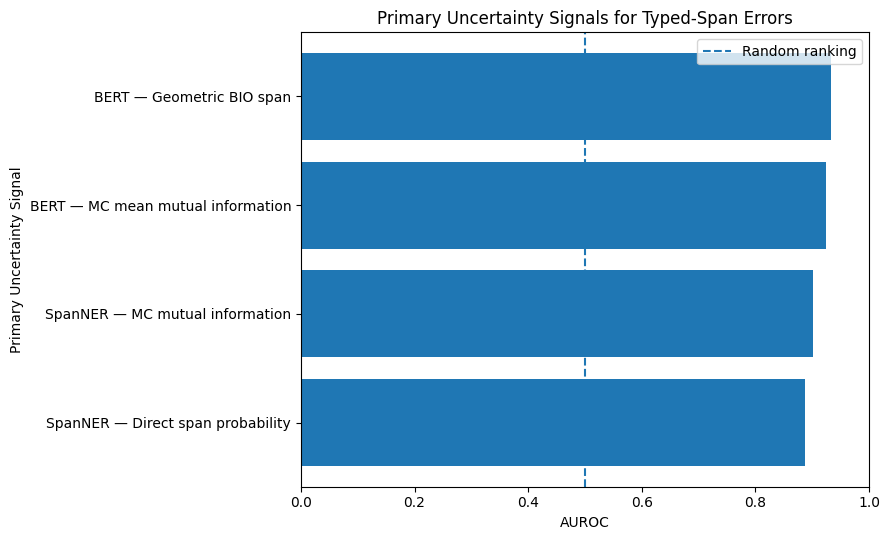

In [31]:
primary_span_metrics_df = (
    primary_formal_metrics_df.loc[
        primary_formal_metrics_df[
            "Event"
        ].eq(
            "span"
        )
    ]
    .copy()
)

primary_span_metrics_df[
    "Plot Label"
] = (
    primary_span_metrics_df[
        "Model"
    ]
    + " — "
    + primary_span_metrics_df[
        "Display Name"
    ]
)


auroc_plot_df = (
    primary_span_metrics_df
    .sort_values(
        "AUROC",
        ascending=True,
    )
)


plt.figure(
    figsize=(9, 5.5)
)

plt.barh(
    auroc_plot_df[
        "Plot Label"
    ],
    auroc_plot_df[
        "AUROC"
    ],
)

plt.axvline(
    0.5,
    linestyle="--",
    label="Random ranking",
)

plt.xlabel(
    "AUROC"
)

plt.ylabel(
    "Primary Uncertainty Signal"
)

plt.title(
    "Primary Uncertainty Signals for Typed-Span Errors"
)

plt.xlim(
    0.0,
    1.0,
)

plt.legend()

plt.tight_layout()


primary_auroc_path = (
    FIGURE_OUTPUT_DIR
    / "primary_span_error_auroc.png"
)

plt.savefig(
    primary_auroc_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 8. Risk–Coverage Analysis

Risk–coverage analysis evaluates the uncertainty signals from a selective-prediction perspective.

For each whole-span uncertainty measure, emitted predictions are ordered from least to most uncertain. Increasingly uncertain predictions are then withheld, leaving only the least uncertain fraction of the original prediction population.

**Coverage** is defined as the proportion of predictions retained, while **risk** is the typed-span error rate among those retained predictions.

A useful uncertainty signal should concentrate errors among the predictions removed first. Consequently, risk should decrease as coverage is reduced. Lower risk at a given coverage and a lower area under the risk–coverage curve (AURC) indicate better selective-prediction behaviour.

The same abstention procedure is applied independently to BERT BIO and SpanNER using their architecture-native uncertainty measures.

## 8.1 Risk–Coverage Calculation

In [32]:
RISK_COVERAGE_CHECKPOINTS = [
    1.00,
    0.95,
    0.90,
    0.80,
    0.70,
]


def calculate_risk_coverage(
    dataframe,
    target_column,
    score_column,
):
    """
    Calculate selective risk as increasingly uncertain
    predictions are withheld.
    """

    analysis_df = dataframe[
        [
            target_column,
            score_column,
        ]
    ].copy()

    analysis_df[
        score_column
    ] = pd.to_numeric(
        analysis_df[
            score_column
        ],
        errors="coerce",
    )

    # Risk–coverage is score-specific because some uncertainty
    # measures may not be available for every prediction.
    analysis_df = (
        analysis_df
        .dropna(
            subset=[
                target_column,
                score_column,
            ]
        )
        .copy()
    )

    analysis_df[
        target_column
    ] = (
        analysis_df[
            target_column
        ]
        .astype(bool)
        .astype(int)
    )

    # Larger values represent greater uncertainty, so ascending
    # order retains the least uncertain predictions first.
    analysis_df = (
        analysis_df
        .sort_values(
            score_column,
            ascending=True,
            kind="stable",
        )
        .reset_index(
            drop=True
        )
    )

    errors = analysis_df[
        target_column
    ].to_numpy(
        dtype=int
    )

    number_of_predictions = int(
        len(
            analysis_df
        )
    )

    retained_counts = np.arange(
        1,
        number_of_predictions + 1,
    )

    coverage = (
        retained_counts
        / number_of_predictions
    )

    cumulative_errors = np.cumsum(
        errors
    )

    risk = (
        cumulative_errors
        / retained_counts
    )

    # Lower AURC indicates that errors are removed earlier as
    # increasingly uncertain predictions are withheld.
    aurc = float(
        np.trapezoid(
            risk,
            coverage,
        )
    )

    checkpoint_records = []

    for requested_coverage in (
        RISK_COVERAGE_CHECKPOINTS
    ):
        retained_count = max(
            1,
            int(
                np.floor(
                    requested_coverage
                    * number_of_predictions
                )
            ),
        )

        checkpoint_records.append({
            "Requested Coverage": float(
                requested_coverage
            ),
            "Actual Coverage": float(
                retained_count
                / number_of_predictions
            ),
            "Retained Predictions": int(
                retained_count
            ),
            "Risk": float(
                cumulative_errors[
                    retained_count - 1
                ]
                / retained_count
            ),
        })

    return {
        "coverage": coverage,
        "risk": risk,
        "aurc": aurc,
        "number_evaluable": (
            number_of_predictions
        ),
        "checkpoints": (
            checkpoint_records
        ),
    }


print(
    "Risk–coverage analysis configured."
)

Risk–coverage analysis configured.


## 8.2 Evaluate All Whole-Span Uncertainty Signals

In [33]:
risk_coverage_records = []
risk_coverage_curves = {}


overall_signal_registry_df = (
    signal_registry_df.loc[
        signal_registry_df[
            "Event"
        ].eq(
            "span"
        )
    ]
    .copy()
)


for _, registry_row in (
    overall_signal_registry_df.iterrows()
):
    model_name = registry_row[
        "Model"
    ]

    signal_name = registry_row[
        "Signal"
    ]

    result = (
        calculate_risk_coverage(
            dataframe=(
                MODEL_DATAFRAMES[
                    model_name
                ]
            ),
            target_column=(
                "event_span_error"
            ),
            score_column=(
                signal_name
            ),
        )
    )

    risk_coverage_curves[
        (
            model_name,
            signal_name,
        )
    ] = result

    record = {
        "Model": model_name,
        "Signal": signal_name,
        "Display Name": (
            registry_row[
                "Display Name"
            ]
        ),
        "Source Family": (
            registry_row[
                "Source Family"
            ]
        ),
        "Signal Role": (
            registry_row[
                "Signal Role"
            ]
        ),
        "Primary": bool(
            registry_row[
                "Primary"
            ]
        ),
        "Evaluable": int(
            result[
                "number_evaluable"
            ]
        ),
        "AURC": float(
            result[
                "aurc"
            ]
        ),
    }

    for checkpoint in (
        result[
            "checkpoints"
        ]
    ):
        coverage_percent = int(
            round(
                100
                * checkpoint[
                    "Requested Coverage"
                ]
            )
        )

        record[
            f"Risk at {coverage_percent}% Coverage"
        ] = float(
            checkpoint[
                "Risk"
            ]
        )

    risk_coverage_records.append(
        record
    )


risk_coverage_summary_df = (
    pd.DataFrame(
        risk_coverage_records
    )
)


risk_coverage_summary_df[
    "AURC Rank"
] = (
    risk_coverage_summary_df
    .groupby(
        "Model"
    )[
        "AURC"
    ]
    .rank(
        ascending=True,
        method="min",
    )
    .astype(int)
)


risk_coverage_summary_df.to_csv(
    RISK_COVERAGE_OUTPUT_DIR
    / "validation_span_risk_coverage.csv",
    index=False,
)


# Keep the displayed table focused on the primary signals.
primary_risk_coverage_df = (
    risk_coverage_summary_df.loc[
        risk_coverage_summary_df[
            "Primary"
        ]
    ]
    .sort_values(
        [
            "Model",
            "AURC",
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "Primary span uncertainty risk–coverage results:"
)

display(
    primary_risk_coverage_df[
        [
            "Model",
            "Display Name",
            "Source Family",
            "Evaluable",
            "AURC",
            "Risk at 100% Coverage",
            "Risk at 95% Coverage",
            "Risk at 90% Coverage",
            "Risk at 80% Coverage",
            "Risk at 70% Coverage",
        ]
    ].round(
        6
    )
)

Primary span uncertainty risk–coverage results:


,Model,Display Name,Source Family,Evaluable,AURC,Risk at 100% Coverage,Risk at 95% Coverage,Risk at 90% Coverage,Risk at 80% Coverage,Risk at 70% Coverage
0,BERT,Geometric BIO span,Deterministic,3039,0.006588,0.059230,0.030135,0.015356,0.009050,0.005642
1,BERT,MC mean mutual information,MC dropout,3039,0.007756,0.059230,0.036024,0.016453,0.009461,0.006112
2,SpanNER,MC mutual information,MC dropout,2978,0.005377,0.037609,0.023330,0.012687,0.007976,0.005758
3,SpanNER,Direct span probability,Deterministic,2978,0.006364,0.037609,0.021209,0.012687,0.008816,0.007198


## 8.3 Best Risk–Coverage Signal by Architecture

In [34]:
best_risk_coverage_df = (
    risk_coverage_summary_df
    .sort_values(
        [
            "Model",
            "AURC",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .groupby(
        "Model",
        as_index=False,
    )
    .first()
)


best_risk_coverage_df.to_csv(
    RISK_COVERAGE_OUTPUT_DIR
    / "best_risk_coverage_signal_by_model.csv",
    index=False,
)


print(
    "Best observed risk–coverage signal by architecture:"
)

display(
    best_risk_coverage_df[
        [
            "Model",
            "Display Name",
            "Source Family",
            "AURC",
            "Risk at 100% Coverage",
            "Risk at 90% Coverage",
            "Risk at 80% Coverage",
            "Risk at 70% Coverage",
        ]
    ].round(
        6
    )
)

Best observed risk–coverage signal by architecture:


,Model,Display Name,Source Family,AURC,Risk at 100% Coverage,Risk at 90% Coverage,Risk at 80% Coverage,Risk at 70% Coverage
0,BERT,MC geometric fixed-label,MC dropout,0.006459,0.059230,0.015356,0.008638,0.005642
1,SpanNER,MC predictive entropy,MC dropout,0.005232,0.037609,0.011940,0.006717,0.005758


## 8.4 Primary Risk–Coverage Curves

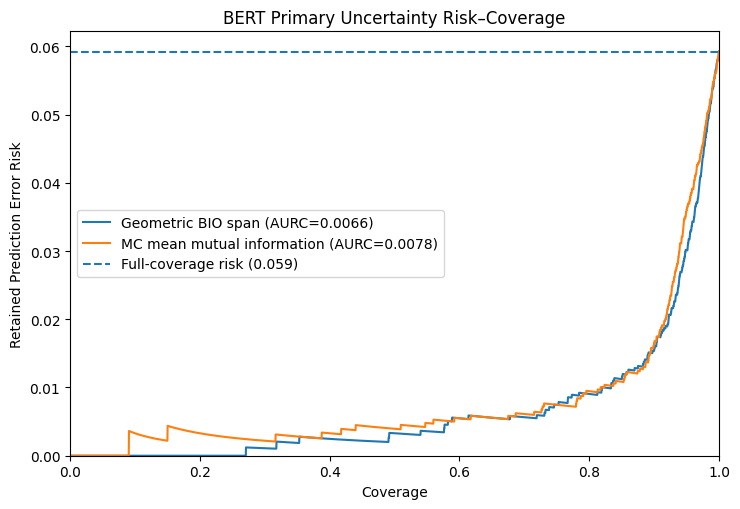

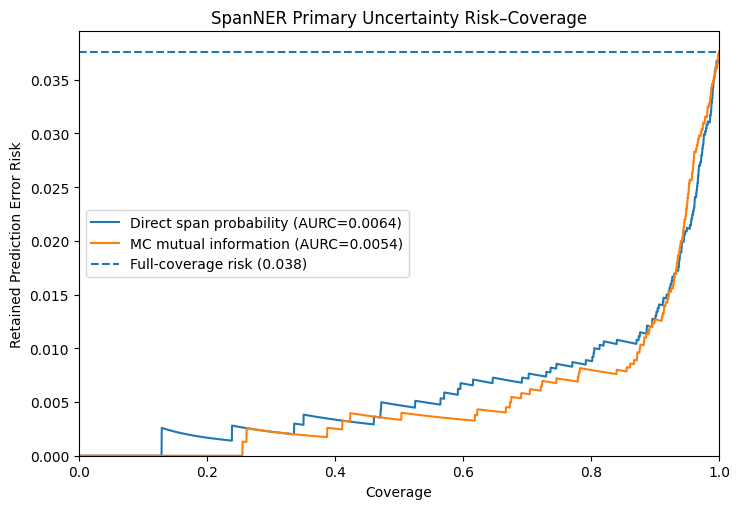

In [35]:
for model_name in [
    "BERT",
    "SpanNER",
]:
    model_primary_signals = (
        overall_signal_registry_df.loc[
            overall_signal_registry_df[
                "Model"
            ].eq(
                model_name
            )
            & overall_signal_registry_df[
                "Primary"
            ].eq(
                True
            )
        ]
    )

    plt.figure(
        figsize=(7.5, 5.2)
    )

    for _, signal_row in (
        model_primary_signals.iterrows()
    ):
        signal_name = (
            signal_row[
                "Signal"
            ]
        )

        result = (
            risk_coverage_curves[
                (
                    model_name,
                    signal_name,
                )
            ]
        )

        plt.plot(
            result[
                "coverage"
            ],
            result[
                "risk"
            ],
            label=(
                f"{signal_row['Display Name']} "
                f"(AURC={result['aurc']:.4f})"
            ),
        )

    full_coverage_risk = float(
        MODEL_DATAFRAMES[
            model_name
        ][
            "event_span_error"
        ]
        .astype(bool)
        .mean()
    )

    plt.axhline(
        full_coverage_risk,
        linestyle="--",
        label=(
            "Full-coverage risk "
            f"({full_coverage_risk:.3f})"
        ),
    )

    plt.xlabel(
        "Coverage"
    )

    plt.ylabel(
        "Retained Prediction Error Risk"
    )

    plt.title(
        f"{model_name} Primary Uncertainty Risk–Coverage"
    )

    plt.xlim(
        0.0,
        1.0,
    )

    plt.ylim(
        bottom=0.0,
    )

    plt.legend()

    plt.tight_layout()

    figure_path = (
        FIGURE_OUTPUT_DIR
        / (
            f"{model_name.lower()}_"
            "primary_risk_coverage.png"
        )
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

## 9. Focused Uncertainty Comparisons

The preceding analysis evaluates uncertainty over each architecture's complete emitted-prediction population. This section performs additional focused comparisons where differences in uncertainty availability or prediction populations could otherwise affect interpretation.

### 9.1 Primary Boundary-Uncertainty Results

The predefined architecture-specific start, end and joint-boundary signals are summarised together.

Boundary errors are rare, so AUROC and AUPRC are interpreted alongside the number of errors, score availability and bootstrap confidence intervals. AUPRC lift over the score-specific prevalence baseline is retained to make the rare-event context explicit.

In [36]:
primary_boundary_df = (
    formal_metrics_df.loc[
        formal_metrics_df[
            "Event"
        ].isin(
            [
                "start",
                "end",
                "joint",
            ]
        )
        & formal_metrics_df[
            "Primary"
        ].eq(True)
    ]
    .copy()
    .sort_values(
        [
            "Event",
            "Model",
            "Source Family",
        ]
    )
    .reset_index(
        drop=True
    )
)

primary_boundary_df.to_csv(
    METRICS_OUTPUT_DIR
    / "primary_boundary_uncertainty_results.csv",
    index=False,
)

print(
    "Primary start, end and joint-boundary uncertainty results:"
)

display(
    primary_boundary_df[
        [
            "Model",
            "Event Display Name",
            "Display Name",
            "Source Family",
            "Evaluable",
            "Errors",
            "Error Prevalence",
            "AUROC",
            "AUROC 95% CI Lower",
            "AUROC 95% CI Upper",
            "AUPRC",
            "AUPRC 95% CI Lower",
            "AUPRC 95% CI Upper",
            "AUPRC Lift over Random",
        ]
    ].round(6)
)

Primary start, end and joint-boundary uncertainty results:


,Model,Event Display Name,Display Name,Source Family,Evaluable,Errors,Error Prevalence,AUROC,AUROC 95% CI Lower,AUROC 95% CI Upper,AUPRC,AUPRC 95% CI Lower,AUPRC 95% CI Upper,AUPRC Lift over Random
0,BERT,Incorrect end boundary,BIO right-continuation ambiguity,Deterministic,2981,29,0.009728,0.938160,0.889001,0.978287,0.528524,0.327639,0.709733,54.328576
1,BERT,Incorrect end boundary,MC BIO right-continuation ambiguity,MC dropout,2981,29,0.009728,0.937798,0.886523,0.978880,0.534974,0.364649,0.741118,54.991612
2,SpanNER,Incorrect end boundary,End boundary competition,Deterministic,2921,14,0.004793,0.848764,0.763438,0.925021,0.039329,0.012176,0.165203,8.205615
3,SpanNER,Incorrect end boundary,MC end boundary competition,MC dropout,2921,14,0.004793,0.866848,0.795494,0.933510,0.050526,0.014452,0.182058,10.541863
4,BERT,Any incorrect boundary,Joint BIO boundary ambiguity,Deterministic,2981,50,0.016773,0.869089,0.769666,0.938169,0.484238,0.318510,0.633995,28.870276
5,BERT,Any incorrect boundary,MC joint BIO boundary ambiguity,MC dropout,2981,50,0.016773,0.873047,0.788916,0.943627,0.488505,0.341883,0.631827,29.124648
6,SpanNER,Any incorrect boundary,Joint boundary competition,Deterministic,2951,28,0.009488,0.829603,0.748137,0.895848,0.049458,0.023505,0.108671,5.212531
7,SpanNER,Any incorrect boundary,MC joint boundary competition,MC dropout,2951,28,0.009488,0.837777,0.756332,0.900935,0.056486,0.028097,0.132825,5.953171
8,BERT,Incorrect start boundary,BIO start ambiguity,Deterministic,2981,23,0.007716,0.854235,0.681201,0.969335,0.444909,0.204450,0.665132,57.664131
9,BERT,Incorrect start boundary,MC BIO start ambiguity,MC dropout,2981,23,0.007716,0.850046,0.719921,0.960981,0.451764,0.202873,0.696495,58.552573


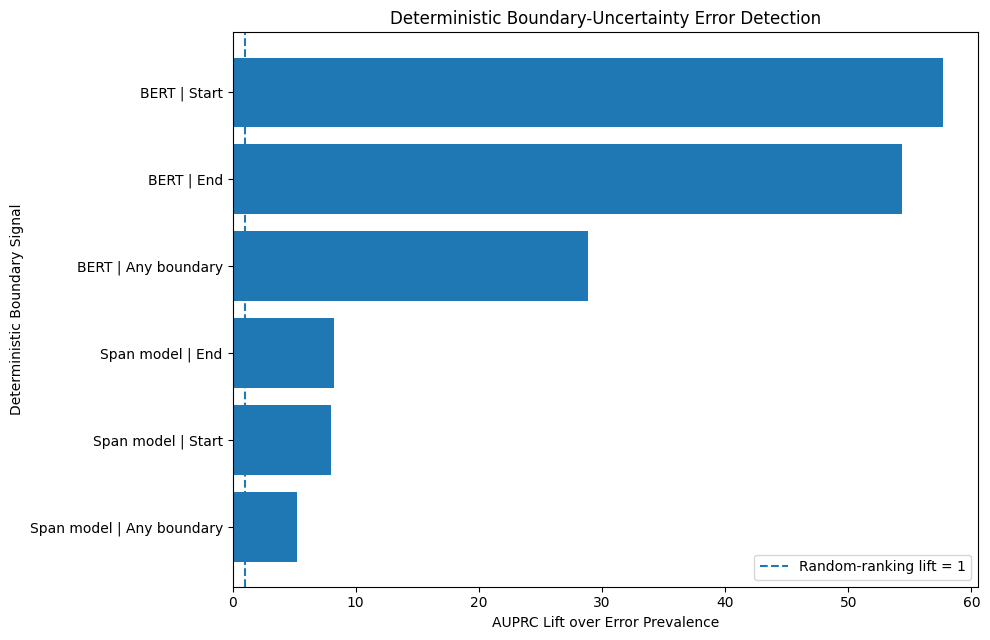

In [37]:
# Main-report Figure 5:
# Primary architecture-native deterministic boundary signals only

boundary_lift_plot_df = (
    primary_boundary_df
    .loc[
        primary_boundary_df["Source Family"].eq("Deterministic")
    ]
    .copy()
)

# Dissertation-friendly labels
boundary_lift_plot_df["Model_Display"] = (
    boundary_lift_plot_df["Model"]
    .replace({"SpanNER": "Span model"})
)

boundary_lift_plot_df["Boundary_Display"] = (
    boundary_lift_plot_df["Event"]
    .replace({
        "start": "Start",
        "end": "End",
        "joint": "Any boundary",
    })
)

boundary_lift_plot_df["Plot_Label"] = (
    boundary_lift_plot_df["Model_Display"]
    + " | "
    + boundary_lift_plot_df["Boundary_Display"]
)

boundary_lift_plot_df = (
    boundary_lift_plot_df
    .sort_values(
        "AUPRC Lift over Random",
        ascending=True,
    )
)

plt.figure(figsize=(10, 6.5))

plt.barh(
    boundary_lift_plot_df["Plot_Label"],
    boundary_lift_plot_df["AUPRC Lift over Random"],
)

plt.axvline(
    1.0,
    linestyle="--",
    label="Random-ranking lift = 1",
)

plt.xlabel(
    "AUPRC Lift over Error Prevalence"
)

plt.ylabel(
    "Deterministic Boundary Signal"
)

plt.title(
    "Deterministic Boundary-Uncertainty Error Detection"
)

plt.legend()
plt.tight_layout()

boundary_lift_path = (
    FIGURE_OUTPUT_DIR
    / "primary_boundary_auprc_lift.png"
)

plt.savefig(
    boundary_lift_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 9.2 Availability-Matched SpanNER Boundary Comparison

SpanNER boundary competition is not defined for every matched prediction because some decoded spans have no valid same-type alternative boundary.

To remove this denominator difference, boundary-competition signals and generic SpanNER uncertainty measures are re-evaluated on exactly the same competitor-available prediction subsets.

Within each boundary event, every reported score therefore uses an identical prediction population, error count and random AUPRC baseline.

In [38]:
availability_matched_specs = [
    {
        "Event": "start",
        "Target": "event_start_error",
        "Availability": (
            "det_start_boundary_competition_uncertainty"
        ),
        "Signals": [
            (
                "det_start_boundary_competition_uncertainty",
                "Start boundary competition",
            ),
            (
                "det_span_probability_uncertainty",
                "Direct span probability",
            ),
            (
                "mc_start_boundary_competition_uncertainty",
                "MC start boundary competition",
            ),
            (
                "mc_span_normalised_mutual_information",
                "MC span mutual information",
            ),
        ],
    },
    {
        "Event": "end",
        "Target": "event_end_error",
        "Availability": (
            "det_end_boundary_competition_uncertainty"
        ),
        "Signals": [
            (
                "det_end_boundary_competition_uncertainty",
                "End boundary competition",
            ),
            (
                "det_span_probability_uncertainty",
                "Direct span probability",
            ),
            (
                "mc_end_boundary_competition_uncertainty",
                "MC end boundary competition",
            ),
            (
                "mc_span_normalised_mutual_information",
                "MC span mutual information",
            ),
        ],
    },
    {
        "Event": "joint",
        "Target": "event_joint_boundary_error",
        "Availability": (
            "det_joint_boundary_competition_uncertainty"
        ),
        "Signals": [
            (
                "det_joint_boundary_competition_uncertainty",
                "Joint boundary competition",
            ),
            (
                "det_span_probability_uncertainty",
                "Direct span probability",
            ),
            (
                "mc_joint_boundary_competition_uncertainty",
                "MC joint boundary competition",
            ),
            (
                "mc_span_normalised_mutual_information",
                "MC span mutual information",
            ),
        ],
    },
]


availability_matched_records = []

for specification_index, specification in enumerate(
    availability_matched_specs
):
    target_column = specification[
        "Target"
    ]

    availability_column = specification[
        "Availability"
    ]

    # Restrict all signals for this event to the exact population
    # on which the architecture-specific competition signal exists.
    matched_subset = spanner_df.loc[
        spanner_df[
            target_column
        ].notna()
        & pd.to_numeric(
            spanner_df[
                availability_column
            ],
            errors="coerce",
        ).notna()
    ].copy()

    for signal_index, (
        signal_column,
        signal_name,
    ) in enumerate(
        specification[
            "Signals"
        ]
    ):
        score_values = pd.to_numeric(
            matched_subset[
                signal_column
            ],
            errors="coerce",
        )

        if score_values.isna().any():
            raise RuntimeError(
                f"Missing {signal_name} values on the "
                f"availability-matched {specification['Event']} subset."
            )

        y_true = (
            matched_subset[
                target_column
            ]
            .astype(bool)
            .astype(int)
            .to_numpy()
        )

        y_score = (
            score_values.to_numpy(
                dtype=float
            )
        )

        prevalence = float(
            y_true.mean()
        )

        bootstrap_interval = (
            cluster_bootstrap_metric_interval(
                dataframe=matched_subset,
                target_column=target_column,
                score_column=signal_column,
                bootstrap_replicates=(
                    BOOTSTRAP_REPLICATES
                ),
                seed=(
                    SEED
                    + 7000
                    + specification_index * 10
                    + signal_index
                ),
            )
        )

        auroc = float(
            roc_auc_score(
                y_true,
                y_score,
            )
        )

        auprc = float(
            average_precision_score(
                y_true,
                y_score,
            )
        )

        availability_matched_records.append({
            "Event": (
                specification[
                    "Event"
                ]
            ),
            "Signal": signal_name,
            "Evaluable": int(
                len(
                    matched_subset
                )
            ),
            "Errors": int(
                y_true.sum()
            ),
            "Error Prevalence": (
                prevalence
            ),
            "AUROC": auroc,
            "AUROC 95% CI Lower": (
                bootstrap_interval[
                    "AUROC 95% CI Lower"
                ]
            ),
            "AUROC 95% CI Upper": (
                bootstrap_interval[
                    "AUROC 95% CI Upper"
                ]
            ),
            "AUPRC": auprc,
            "AUPRC 95% CI Lower": (
                bootstrap_interval[
                    "AUPRC 95% CI Lower"
                ]
            ),
            "AUPRC 95% CI Upper": (
                bootstrap_interval[
                    "AUPRC 95% CI Upper"
                ]
            ),
            "Random AUPRC Baseline": (
                prevalence
            ),
            "AUPRC Lift over Random": (
                auprc
                / prevalence
            ),
        })


availability_matched_df = pd.DataFrame(
    availability_matched_records
)

availability_matched_df.to_csv(
    METRICS_OUTPUT_DIR
    / "spanner_boundary_availability_matched_comparison.csv",
    index=False,
)


print(
    "SpanNER availability-matched boundary comparison:"
)

display(
    availability_matched_df.round(
        6
    )
)

SpanNER availability-matched boundary comparison:


,Event,Signal,Evaluable,Errors,Error Prevalence,AUROC,AUROC 95% CI Lower,AUROC 95% CI Upper,AUPRC,AUPRC 95% CI Lower,AUPRC 95% CI Upper,Random AUPRC Baseline,AUPRC Lift over Random
0,start,Start boundary competition,2452,15,0.006117,0.852633,0.737342,0.950099,0.048918,0.019090,0.139955,0.006117,7.996478
1,start,Direct span probability,2452,15,0.006117,0.868335,0.778899,0.943178,0.105164,0.017943,0.297145,0.006117,17.190886
2,start,MC start boundary competition,2452,15,0.006117,0.852332,0.710820,0.952989,0.048255,0.015439,0.126607,0.006117,7.888063
3,start,MC span mutual information,2452,15,0.006117,0.886937,0.838733,0.935478,0.035828,0.016154,0.089759,0.006117,5.856751
4,end,End boundary competition,2921,14,0.004793,0.848764,0.768273,0.917909,0.039329,0.011437,0.153844,0.004793,8.205615
5,end,Direct span probability,2921,14,0.004793,0.832154,0.673946,0.941116,0.102329,0.014888,0.271440,0.004793,21.350135
6,end,MC end boundary competition,2921,14,0.004793,0.866848,0.799204,0.937650,0.050526,0.015845,0.193342,0.004793,10.541863
7,end,MC span mutual information,2921,14,0.004793,0.867659,0.767745,0.956846,0.074140,0.017355,0.209297,0.004793,15.468883
8,joint,Joint boundary competition,2951,28,0.009488,0.829603,0.748396,0.891701,0.049458,0.026899,0.119413,0.009488,5.212531
9,joint,Direct span probability,2951,28,0.009488,0.851755,0.770009,0.920233,0.092651,0.034014,0.182846,0.009488,9.764802


### 9.3 Paired Common-Span Comparison

The architecture-specific analyses use different emitted prediction populations. A paired comparison is therefore constructed using only typed spans emitted identically by both models.

A common prediction must have the same source sentence, start boundary, end boundary and predicted entity type in both BERT BIO and SpanNER.

The primary deterministic and MC-Dropout span-level uncertainty measures are then evaluated on this shared prediction population. All four signals consequently use the same exact-correctness labels, error prevalence and random AUPRC baseline.

In [39]:
COMMON_SPAN_KEYS = [
    "source_index",
    "pred_start",
    "pred_end",
    "pred_type",
]


bert_common_source = (
    bert_df[
        [
            *COMMON_SPAN_KEYS,
            "sentence_index",
            "is_exact_correct",
            "det_span_geometric_uncertainty",
            "mc_span_mean_normalised_mutual_information",
        ]
    ]
    .copy()
    .rename(
        columns={
            "sentence_index":
                "bert_sentence_index",

            "is_exact_correct":
                "bert_is_exact_correct",

            "det_span_geometric_uncertainty":
                "bert_primary_deterministic",

            "mc_span_mean_normalised_mutual_information":
                "bert_primary_mc",
        }
    )
)


spanner_common_source = (
    spanner_df[
        [
            *COMMON_SPAN_KEYS,
            "sentence_index",
            "is_exact_correct",
            "det_span_probability_uncertainty",
            "mc_span_normalised_mutual_information",
        ]
    ]
    .copy()
    .rename(
        columns={
            "sentence_index":
                "spanner_sentence_index",

            "is_exact_correct":
                "spanner_is_exact_correct",

            "det_span_probability_uncertainty":
                "spanner_primary_deterministic",

            "mc_span_normalised_mutual_information":
                "spanner_primary_mc",
        }
    )
)


common_span_df = (
    bert_common_source.merge(
        spanner_common_source,
        on=COMMON_SPAN_KEYS,
        how="inner",
        validate="one_to_one",
    )
)


# Identical typed predictions must have the same correctness label.
exact_label_mismatches = int(
    (
        common_span_df[
            "bert_is_exact_correct"
        ].astype(bool)
        != common_span_df[
            "spanner_is_exact_correct"
        ].astype(bool)
    ).sum()
)

if exact_label_mismatches != 0:
    raise RuntimeError(
        "Exact-correctness disagreement found for identical typed spans."
    )


common_span_df[
    "sentence_index"
] = (
    common_span_df[
        "bert_sentence_index"
    ].astype(int)
)

common_span_df[
    "common_span_error"
] = (
    ~common_span_df[
        "bert_is_exact_correct"
    ].astype(bool)
)


common_span_summary_df = pd.DataFrame([
    {
        "Measure": (
            "BERT emitted predictions"
        ),
        "Count": len(
            bert_df
        ),
    },
    {
        "Measure": (
            "SpanNER emitted predictions"
        ),
        "Count": len(
            spanner_df
        ),
    },
    {
        "Measure": (
            "Common identical typed spans"
        ),
        "Count": len(
            common_span_df
        ),
    },
    {
        "Measure": (
            "BERT-only typed spans"
        ),
        "Count": (
            len(bert_df)
            - len(
                common_span_df
            )
        ),
    },
    {
        "Measure": (
            "SpanNER-only typed spans"
        ),
        "Count": (
            len(spanner_df)
            - len(
                common_span_df
            )
        ),
    },
    {
        "Measure": (
            "Errors among common typed spans"
        ),
        "Count": int(
            common_span_df[
                "common_span_error"
            ].sum()
        ),
    },
])


common_span_summary_df.to_csv(
    TABLE_OUTPUT_DIR
    / "common_span_population_summary.csv",
    index=False,
)

common_span_df.to_csv(
    TABLE_OUTPUT_DIR
    / "paired_common_typed_spans.csv",
    index=False,
)


print(
    "BERT–SpanNER common typed-span population:"
)

display(
    common_span_summary_df
)

BERT–SpanNER common typed-span population:


,Measure,Count
0,BERT emitted predictions,3039
1,SpanNER emitted predictions,2978
2,Common identical typed spans,2890
3,BERT-only typed spans,149
4,SpanNER-only typed spans,88
5,Errors among common typed spans,72


### Shared Boundary-Error Overlap

In [40]:
# Compare whether BERT BIO and SpanNER make boundary errors
# on the same identically emitted typed spans.

BOUNDARY_OVERLAP_SPECS = {
    "Start boundary": {
        "event_column": "event_start_error",
        "bert_signal": "det_start_bio_boundary_uncertainty",
        "spanner_signal": "det_start_boundary_competition_uncertainty",
    },
    "End boundary": {
        "event_column": "event_end_error",
        "bert_signal": "det_end_bio_continuation_uncertainty",
        "spanner_signal": "det_end_boundary_competition_uncertainty",
    },
    "Any boundary": {
        "event_column": "event_joint_boundary_error",
        "bert_signal": "det_joint_bio_boundary_uncertainty",
        "spanner_signal": "det_joint_boundary_competition_uncertainty",
    },
}


bert_boundary_source = (
    bert_df[
        [
            *COMMON_SPAN_KEYS,
            "event_start_error",
            "event_end_error",
            "event_joint_boundary_error",
            "det_start_bio_boundary_uncertainty",
            "det_end_bio_continuation_uncertainty",
            "det_joint_bio_boundary_uncertainty",
        ]
    ]
    .copy()
    .rename(
        columns={
            "event_start_error": "bert_event_start_error",
            "event_end_error": "bert_event_end_error",
            "event_joint_boundary_error": "bert_event_joint_boundary_error",
            "det_start_bio_boundary_uncertainty":
                "bert_det_start_boundary_uncertainty",
            "det_end_bio_continuation_uncertainty":
                "bert_det_end_boundary_uncertainty",
            "det_joint_bio_boundary_uncertainty":
                "bert_det_joint_boundary_uncertainty",
        }
    )
)


spanner_boundary_source = (
    spanner_df[
        [
            *COMMON_SPAN_KEYS,
            "event_start_error",
            "event_end_error",
            "event_joint_boundary_error",
            "det_start_boundary_competition_uncertainty",
            "det_end_boundary_competition_uncertainty",
            "det_joint_boundary_competition_uncertainty",
        ]
    ]
    .copy()
    .rename(
        columns={
            "event_start_error": "spanner_event_start_error",
            "event_end_error": "spanner_event_end_error",
            "event_joint_boundary_error":
                "spanner_event_joint_boundary_error",
            "det_start_boundary_competition_uncertainty":
                "spanner_det_start_boundary_uncertainty",
            "det_end_boundary_competition_uncertainty":
                "spanner_det_end_boundary_uncertainty",
            "det_joint_boundary_competition_uncertainty":
                "spanner_det_joint_boundary_uncertainty",
        }
    )
)


common_boundary_df = (
    bert_boundary_source.merge(
        spanner_boundary_source,
        on=COMMON_SPAN_KEYS,
        how="inner",
        validate="one_to_one",
    )
)


overlap_records = []

for event_name, specification in BOUNDARY_OVERLAP_SPECS.items():

    event_suffix = specification["event_column"].replace(
        "event_",
        ""
    )

    bert_event_column = (
        f"bert_event_{event_suffix}"
    )

    spanner_event_column = (
        f"spanner_event_{event_suffix}"
    )

    # Match the populations used by the primary deterministic
    # boundary-uncertainty analyses in Table 9:
    # both correctness labels must exist and both architecture-specific
    # deterministic uncertainty signals must be available.
    if event_name == "Start boundary":
        bert_signal_column = (
            "bert_det_start_boundary_uncertainty"
        )
        spanner_signal_column = (
            "spanner_det_start_boundary_uncertainty"
        )
    elif event_name == "End boundary":
        bert_signal_column = (
            "bert_det_end_boundary_uncertainty"
        )
        spanner_signal_column = (
            "spanner_det_end_boundary_uncertainty"
        )
    else:
        bert_signal_column = (
            "bert_det_joint_boundary_uncertainty"
        )
        spanner_signal_column = (
            "spanner_det_joint_boundary_uncertainty"
        )

    paired = common_boundary_df.loc[
        common_boundary_df[
            bert_event_column
        ].notna()
        & common_boundary_df[
            spanner_event_column
        ].notna()
        & pd.to_numeric(
            common_boundary_df[
                bert_signal_column
            ],
            errors="coerce",
        ).notna()
        & pd.to_numeric(
            common_boundary_df[
                spanner_signal_column
            ],
            errors="coerce",
        ).notna()
    ].copy()

    bert_error = (
        paired[
            bert_event_column
        ]
        .astype(bool)
    )

    spanner_error = (
        paired[
            spanner_event_column
        ]
        .astype(bool)
    )

    shared_error = (
        bert_error
        & spanner_error
    )

    bert_only_error = (
        bert_error
        & ~spanner_error
    )

    spanner_only_error = (
        ~bert_error
        & spanner_error
    )

    either_error = (
        bert_error
        | spanner_error
    )

    overlap_records.append({
        "Boundary event": event_name,
        "Common spans evaluable by both": int(
            len(paired)
        ),
        "BERT errors on common population": int(
            bert_error.sum()
        ),
        "SpanNER errors on common population": int(
            spanner_error.sum()
        ),
        "Shared errors": int(
            shared_error.sum()
        ),
        "BERT-only errors": int(
            bert_only_error.sum()
        ),
        "SpanNER-only errors": int(
            spanner_only_error.sum()
        ),
        "Either model error": int(
            either_error.sum()
        ),
        "Shared / BERT errors (%)": (
            100.0
            * shared_error.sum()
            / bert_error.sum()
            if bert_error.sum() > 0
            else np.nan
        ),
        "Shared / SpanNER errors (%)": (
            100.0
            * shared_error.sum()
            / spanner_error.sum()
            if spanner_error.sum() > 0
            else np.nan
        ),
        "Error-set Jaccard (%)": (
            100.0
            * shared_error.sum()
            / either_error.sum()
            if either_error.sum() > 0
            else np.nan
        ),
    })


boundary_error_overlap_df = pd.DataFrame(
    overlap_records
)


boundary_error_overlap_df.to_csv(
    TABLE_OUTPUT_DIR
    / "paired_boundary_error_overlap.csv",
    index=False,
)


print(
    "Boundary-error overlap on identically emitted BERT–SpanNER typed spans:"
)

display(
    boundary_error_overlap_df.round(2)
)

Boundary-error overlap on identically emitted BERT–SpanNER typed spans:


,Boundary event,Common spans evaluable by both,BERT errors on common population,SpanNER errors on common population,Shared errors,BERT-only errors,SpanNER-only errors,Either model error,Shared / BERT errors (%),Shared / SpanNER errors (%),Error-set Jaccard (%)
0,Start boundary,2378,9,9,9,0,0,9,100.0,100.0,100.0
1,End boundary,2838,6,6,6,0,0,6,100.0,100.0,100.0
2,Any boundary,2868,15,15,15,0,0,15,100.0,100.0,100.0


In [41]:
# Gold-entity-level overlap of boundary errors between BERT BIO and SpanNER.
# This answers whether the two architectures make boundary mistakes
# on the same underlying annotated entities, even when their predicted
# spans themselves differ.

GOLD_ENTITY_KEYS = [
    "source_index",
    "gold_start",
    "gold_end",
    "gold_entity_type",
]


def prepare_gold_boundary_view(
    matching_df,
    prefix,
):
    # Restrict to matched prediction–gold pairs.
    # Unmatched false negatives have no prediction-side boundary
    # uncertainty event and are not part of Table 9's discrimination population.
    matched = matching_df.loc[
        matching_df["row_source"].eq("matched_pair")
        & matching_df["gold_start"].notna()
    ].copy()

    for column in [
        "source_index",
        "gold_start",
        "gold_end",
    ]:
        matched[column] = pd.to_numeric(
            matched[column],
            errors="raise",
        ).astype(int)

    matched["gold_entity_type"] = (
        matched["gold_entity_type"].astype(str)
    )

    matched[f"{prefix}_start_error"] = (
        ~matched["is_start_correct"].astype(bool)
    )

    matched[f"{prefix}_end_error"] = (
        ~matched["is_end_correct"].astype(bool)
    )

    matched[f"{prefix}_any_boundary_error"] = (
        ~matched["is_boundary_correct"].astype(bool)
    )

    return matched[
        [
            *GOLD_ENTITY_KEYS,
            f"{prefix}_start_error",
            f"{prefix}_end_error",
            f"{prefix}_any_boundary_error",
        ]
    ].copy()


bert_gold_boundary = prepare_gold_boundary_view(
    bert_matching_df,
    "bert",
)

spanner_gold_boundary = prepare_gold_boundary_view(
    spanner_matching_df,
    "spanner",
)


# Compare only gold entities that received a matched prediction
# from both architectures.
paired_gold_boundary = bert_gold_boundary.merge(
    spanner_gold_boundary,
    on=GOLD_ENTITY_KEYS,
    how="inner",
    validate="one_to_one",
)


overlap_rows = []

for event_name, bert_col, spanner_col in [
    (
        "Start boundary",
        "bert_start_error",
        "spanner_start_error",
    ),
    (
        "End boundary",
        "bert_end_error",
        "spanner_end_error",
    ),
    (
        "Any boundary",
        "bert_any_boundary_error",
        "spanner_any_boundary_error",
    ),
]:
    bert_error = paired_gold_boundary[
        bert_col
    ].astype(bool)

    spanner_error = paired_gold_boundary[
        spanner_col
    ].astype(bool)

    shared = bert_error & spanner_error
    bert_only = bert_error & ~spanner_error
    spanner_only = ~bert_error & spanner_error
    either = bert_error | spanner_error

    overlap_rows.append({
        "Boundary event": event_name,
        "Gold entities matched by both": int(
            len(paired_gold_boundary)
        ),
        "BERT errors": int(
            bert_error.sum()
        ),
        "SpanNER errors": int(
            spanner_error.sum()
        ),
        "Shared errors": int(
            shared.sum()
        ),
        "BERT-only errors": int(
            bert_only.sum()
        ),
        "SpanNER-only errors": int(
            spanner_only.sum()
        ),
        "Either-model errors": int(
            either.sum()
        ),
        "Shared / BERT errors (%)": (
            100.0 * shared.sum() / bert_error.sum()
            if bert_error.sum() > 0
            else np.nan
        ),
        "Shared / SpanNER errors (%)": (
            100.0 * shared.sum() / spanner_error.sum()
            if spanner_error.sum() > 0
            else np.nan
        ),
        "Jaccard overlap (%)": (
            100.0 * shared.sum() / either.sum()
            if either.sum() > 0
            else np.nan
        ),
    })


gold_boundary_error_overlap_df = pd.DataFrame(
    overlap_rows
)

gold_boundary_error_overlap_df.to_csv(
    TABLE_OUTPUT_DIR
    / "gold_entity_boundary_error_overlap.csv",
    index=False,
)

print(
    "Boundary-error overlap on the same underlying gold entities:"
)

display(
    gold_boundary_error_overlap_df.round(2)
)

Boundary-error overlap on the same underlying gold entities:


,Boundary event,Gold entities matched by both,BERT errors,SpanNER errors,Shared errors,BERT-only errors,SpanNER-only errors,Either-model errors,Shared / BERT errors (%),Shared / SpanNER errors (%),Jaccard overlap (%)
0,Start boundary,2943,17,13,9,8,4,21,52.94,69.23,42.86
1,End boundary,2943,24,13,9,15,4,28,37.50,69.23,32.14
2,Any boundary,2943,40,26,21,19,5,45,52.50,80.77,46.67


### Evaluate the four primary signals

In [42]:
COMMON_SIGNAL_SPECS = [
    {
        "Model": "BERT",
        "Source Family": (
            "Deterministic"
        ),
        "Display Name": (
            "Geometric BIO span"
        ),
        "Signal": (
            "bert_primary_deterministic"
        ),
    },
    {
        "Model": "BERT",
        "Source Family": (
            "MC dropout"
        ),
        "Display Name": (
            "MC mean mutual information"
        ),
        "Signal": (
            "bert_primary_mc"
        ),
    },
    {
        "Model": "SpanNER",
        "Source Family": (
            "Deterministic"
        ),
        "Display Name": (
            "Direct span probability"
        ),
        "Signal": (
            "spanner_primary_deterministic"
        ),
    },
    {
        "Model": "SpanNER",
        "Source Family": (
            "MC dropout"
        ),
        "Display Name": (
            "MC mutual information"
        ),
        "Signal": (
            "spanner_primary_mc"
        ),
    },
]


common_metric_records = []

for signal_index, specification in enumerate(
    COMMON_SIGNAL_SPECS
):
    signal = specification[
        "Signal"
    ]

    analysis_df = (
        common_span_df[
            [
                "sentence_index",
                "common_span_error",
                signal,
            ]
        ]
        .copy()
    )

    analysis_df[
        signal
    ] = pd.to_numeric(
        analysis_df[
            signal
        ],
        errors="coerce",
    )

    analysis_df = (
        analysis_df
        .dropna()
        .reset_index(
            drop=True
        )
    )

    y_true = (
        analysis_df[
            "common_span_error"
        ]
        .astype(int)
        .to_numpy()
    )

    y_score = (
        analysis_df[
            signal
        ]
        .to_numpy(
            dtype=float
        )
    )

    prevalence = float(
        y_true.mean()
    )

    auroc = float(
        roc_auc_score(
            y_true,
            y_score,
        )
    )

    auprc = float(
        average_precision_score(
            y_true,
            y_score,
        )
    )

    bootstrap_interval = (
        cluster_bootstrap_metric_interval(
            dataframe=analysis_df,
            target_column=(
                "common_span_error"
            ),
            score_column=signal,
            bootstrap_replicates=(
                BOOTSTRAP_REPLICATES
            ),
            seed=(
                SEED
                + 5000
                + signal_index
            ),
        )
    )

    common_metric_records.append({
        "Model": (
            specification[
                "Model"
            ]
        ),
        "Source Family": (
            specification[
                "Source Family"
            ]
        ),
        "Display Name": (
            specification[
                "Display Name"
            ]
        ),
        "Evaluable": int(
            len(
                analysis_df
            )
        ),
        "Errors": int(
            y_true.sum()
        ),
        "Error Prevalence": (
            prevalence
        ),
        "AUROC": auroc,
        "AUROC 95% CI Lower": (
            bootstrap_interval[
                "AUROC 95% CI Lower"
            ]
        ),
        "AUROC 95% CI Upper": (
            bootstrap_interval[
                "AUROC 95% CI Upper"
            ]
        ),
        "AUPRC": auprc,
        "AUPRC 95% CI Lower": (
            bootstrap_interval[
                "AUPRC 95% CI Lower"
            ]
        ),
        "AUPRC 95% CI Upper": (
            bootstrap_interval[
                "AUPRC 95% CI Upper"
            ]
        ),
        "Random AUPRC Baseline": (
            prevalence
        ),
        "AUPRC Lift over Random": (
            auprc
            / prevalence
        ),
    })


common_span_metrics_df = pd.DataFrame(
    common_metric_records
)

common_span_metrics_df.to_csv(
    METRICS_OUTPUT_DIR
    / "paired_common_span_primary_metrics.csv",
    index=False,
)


print(
    "Primary uncertainty on common BERT–SpanNER typed spans:"
)

display(
    common_span_metrics_df.round(
        6
    )
)

Primary uncertainty on common BERT–SpanNER typed spans:


,Model,Source Family,Display Name,Evaluable,Errors,Error Prevalence,AUROC,AUROC 95% CI Lower,AUROC 95% CI Upper,AUPRC,AUPRC 95% CI Lower,AUPRC 95% CI Upper,Random AUPRC Baseline,AUPRC Lift over Random
0,BERT,Deterministic,Geometric BIO span,2890,72,0.024913,0.881592,0.844398,0.918217,0.216955,0.154950,0.320123,0.024913,8.708344
1,BERT,MC dropout,MC mean mutual information,2890,72,0.024913,0.865591,0.816156,0.902437,0.193493,0.129104,0.282580,0.024913,7.766588
2,SpanNER,Deterministic,Direct span probability,2890,72,0.024913,0.865217,0.823933,0.903103,0.237365,0.152976,0.348405,0.024913,9.527574
3,SpanNER,MC dropout,MC mutual information,2890,72,0.024913,0.879539,0.842029,0.916662,0.206415,0.143894,0.300775,0.024913,8.285280


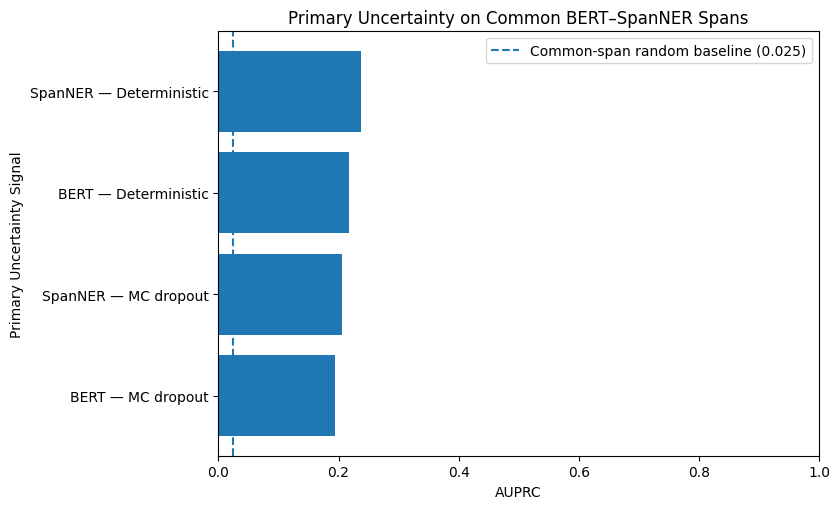

In [43]:
common_plot_df = (
    common_span_metrics_df
    .assign(
        Plot_Label=lambda frame: (
            frame[
                "Model"
            ]
            + " — "
            + frame[
                "Source Family"
            ]
        )
    )
    .sort_values(
        "AUPRC",
        ascending=True,
    )
)


common_random_baseline = float(
    common_span_metrics_df[
        "Random AUPRC Baseline"
    ].iloc[0]
)


plt.figure(
    figsize=(8.5, 5.2)
)

plt.barh(
    common_plot_df[
        "Plot_Label"
    ],
    common_plot_df[
        "AUPRC"
    ],
)

plt.axvline(
    common_random_baseline,
    linestyle="--",
    label=(
        "Common-span random baseline "
        f"({common_random_baseline:.3f})"
    ),
)

plt.xlabel(
    "AUPRC"
)

plt.ylabel(
    "Primary Uncertainty Signal"
)

plt.title(
    "Primary Uncertainty on Common BERT–SpanNER Spans"
)

plt.xlim(
    0.0,
    1.0,
)

plt.legend()
plt.tight_layout()

common_auprc_path = (
    FIGURE_OUTPUT_DIR
    / "common_span_primary_auprc.png"
)

plt.savefig(
    common_auprc_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 9.4 Agreement Between Architecture-Specific Uncertainty Rankings

Spearman rank correlation is used to examine whether BERT BIO and SpanNER assign high uncertainty to the same predictions within the paired common-span population.

The analysis compares deterministic signals with deterministic signals and MC-Dropout signals with MC-Dropout signals. A low correlation would indicate that the architectures capture different uncertainty patterns even when they emit the same typed span.

In [44]:
from scipy.stats import spearmanr


paired_rank_records = []

for (
    family_name,
    bert_signal,
    spanner_signal,
) in [
    (
        "Deterministic",
        "bert_primary_deterministic",
        "spanner_primary_deterministic",
    ),
    (
        "MC dropout",
        "bert_primary_mc",
        "spanner_primary_mc",
    ),
]:
    paired_df = (
        common_span_df[
            [
                bert_signal,
                spanner_signal,
            ]
        ]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .dropna()
    )

    rho, p_value = spearmanr(
        paired_df[
            bert_signal
        ],
        paired_df[
            spanner_signal
        ],
    )

    paired_rank_records.append({
        "Signal Family": (
            family_name
        ),
        "Common Spans": int(
            len(
                paired_df
            )
        ),
        "Spearman Rho": float(
            rho
        ),
        "Spearman p-value": float(
            p_value
        ),
    })


paired_rank_correlation_df = (
    pd.DataFrame(
        paired_rank_records
    )
)

paired_rank_correlation_df.to_csv(
    METRICS_OUTPUT_DIR
    / "common_span_rank_correlations.csv",
    index=False,
)


print(
    "BERT–SpanNER uncertainty ranking agreement:"
)

display(
    paired_rank_correlation_df.round(
        6
    )
)

BERT–SpanNER uncertainty ranking agreement:


,Signal Family,Common Spans,Spearman Rho,Spearman p-value
0,Deterministic,2890,0.602617,0.0
1,MC dropout,2890,0.614435,0.0


### 9.5 Primary MC-Dropout Signal versus Deterministic Baseline

For each architecture and error event, the predefined primary MC-Dropout signal is compared directly with the corresponding predefined deterministic uncertainty signal.

Positive differences indicate improved discrimination from MC Dropout, while negative differences indicate that the deterministic architecture-native signal performed better.

These differences are interpreted together with their evaluable sample sizes and bootstrap intervals rather than as independent significance tests.

In [45]:
primary_mc_comparison_records = []

for model_name in [
    "BERT",
    "SpanNER",
]:
    for event in [
        "span",
        "start",
        "end",
        "joint",
    ]:
        event_primary_df = (
            formal_metrics_df.loc[
                formal_metrics_df[
                    "Model"
                ].eq(
                    model_name
                )
                & formal_metrics_df[
                    "Event"
                ].eq(
                    event
                )
                & formal_metrics_df[
                    "Primary"
                ].eq(
                    True
                )
            ]
        )

        deterministic_row = (
            event_primary_df.loc[
                event_primary_df[
                    "Source Family"
                ].eq(
                    "Deterministic"
                )
            ]
            .iloc[0]
        )

        mc_row = (
            event_primary_df.loc[
                event_primary_df[
                    "Source Family"
                ].eq(
                    "MC dropout"
                )
            ]
            .iloc[0]
        )

        primary_mc_comparison_records.append({
            "Model": (
                model_name
            ),
            "Event": (
                EVENT_DISPLAY_NAMES[
                    event
                ]
            ),
            "Deterministic Signal": (
                deterministic_row[
                    "Display Name"
                ]
            ),
            "Deterministic Evaluable": int(
                deterministic_row[
                    "Evaluable"
                ]
            ),
            "Deterministic AUROC": float(
                deterministic_row[
                    "AUROC"
                ]
            ),
            "Deterministic AUPRC": float(
                deterministic_row[
                    "AUPRC"
                ]
            ),
            "MC Signal": (
                mc_row[
                    "Display Name"
                ]
            ),
            "MC Evaluable": int(
                mc_row[
                    "Evaluable"
                ]
            ),
            "MC AUROC": float(
                mc_row[
                    "AUROC"
                ]
            ),
            "MC AUPRC": float(
                mc_row[
                    "AUPRC"
                ]
            ),
            "MC − Deterministic AUROC": float(
                mc_row[
                    "AUROC"
                ]
                - deterministic_row[
                    "AUROC"
                ]
            ),
            "MC − Deterministic AUPRC": float(
                mc_row[
                    "AUPRC"
                ]
                - deterministic_row[
                    "AUPRC"
                ]
            ),
        })


primary_mc_comparison_df = pd.DataFrame(
    primary_mc_comparison_records
)

primary_mc_comparison_df.to_csv(
    METRICS_OUTPUT_DIR
    / "primary_mc_vs_deterministic_comparison.csv",
    index=False,
)


print(
    "Primary MC Dropout versus deterministic uncertainty:"
)

display(
    primary_mc_comparison_df.round(
        6
    )
)

Primary MC Dropout versus deterministic uncertainty:


,Model,Event,Deterministic Signal,Deterministic Evaluable,Deterministic AUROC,Deterministic AUPRC,MC Signal,MC Evaluable,MC AUROC,MC AUPRC,MC − Deterministic AUROC,MC − Deterministic AUPRC
0,BERT,Incorrect typed span,Geometric BIO span,3039,0.933470,0.541155,MC mean mutual information,3039,0.924535,0.484342,-0.008936,-0.056812
1,BERT,Incorrect start boundary,BIO start ambiguity,2981,0.854235,0.444909,MC BIO start ambiguity,2981,0.850046,0.451764,-0.004189,0.006855
2,BERT,Incorrect end boundary,BIO right-continuation ambiguity,2981,0.938160,0.528524,MC BIO right-continuation ambiguity,2981,0.937798,0.534974,-0.000362,0.006450
3,BERT,Any incorrect boundary,Joint BIO boundary ambiguity,2981,0.869089,0.484238,MC joint BIO boundary ambiguity,2981,0.873047,0.488505,0.003958,0.004267
4,SpanNER,Incorrect typed span,Direct span probability,2978,0.887841,0.315247,MC mutual information,2978,0.901502,0.282494,0.013661,-0.032753
5,SpanNER,Incorrect start boundary,Start boundary competition,2452,0.852633,0.048918,MC start boundary competition,2452,0.852332,0.048255,-0.000301,-0.000663
6,SpanNER,Incorrect end boundary,End boundary competition,2921,0.848764,0.039329,MC end boundary competition,2921,0.866848,0.050526,0.018084,0.011197
7,SpanNER,Any incorrect boundary,Joint boundary competition,2951,0.829603,0.049458,MC joint boundary competition,2951,0.837777,0.056486,0.008174,0.007027


## 10. Final Comparison Summary

The architecture comparison produced three principal findings.

First, SpanNER achieved stronger strict typed-span performance than BERT BIO on the frozen validation population. This advantage remained after restricting both architectures to the shared width-four support, indicating that the difference was not explained solely by SpanNER's candidate-width restriction.

Second, both architectures produced uncertainty signals that ranked prediction errors substantially above chance, but their boundary-specific behaviour differed. BERT's BIO-derived boundary ambiguity was particularly effective for identifying boundary errors. SpanNER's candidate-local boundary competition also contained useful ranking information, although availability-matched comparisons showed that its broader span-level uncertainty often provided stronger error retrieval.

Third, MC Dropout did not provide a consistent improvement over deterministic uncertainty. Improvements occurred for some events and metrics, but deterministic signals were equal or stronger elsewhere. Risk–coverage analysis nevertheless showed that uncertainty from both architectures can support selective prediction by reducing retained error risk as uncertain predictions are withheld.

A paired analysis of 2,890 typed spans emitted identically by both architectures showed only moderate agreement between their uncertainty rankings, indicating that BERT BIO and SpanNER capture overlapping but non-identical uncertainty structure.

These validation analyses establish the uncertainty signals carried forward into the subsequent calibration and conformal-prediction stages. No probability calibration or conformal threshold is fitted in this notebook, and the official CoNLL-2003 test population remains reserved for the final locked evaluation.

In [46]:
headline_architecture_df = (
    final_architecture_summary_df.copy()
)

headline_architecture_df.to_csv(
    TABLE_OUTPUT_DIR
    / "headline_architecture_results.csv",
    index=False,
)

print(
    "Headline architecture results:"
)

display(
    headline_architecture_df.round(6)
)

Headline architecture results:


,Model,Condition,Gold Entities,Precision,Recall,F1,Start Errors,End Errors
0,BERT BIO,Native,3011,0.940770,0.949518,0.945124,23,29
1,SpanNER,Native,3011,0.962391,0.951843,0.957088,15,14
2,BERT BIO,Matched width ≤ 4,2993,0.941138,0.950885,0.945986,20,25
3,SpanNER,Matched width ≤ 4,2993,0.962391,0.957568,0.959973,13,12


## 10.2 Headline Uncertainty Results

In [47]:
# Retain the predefined deterministic architecture-native signals
# as the concise headline uncertainty comparison.
headline_uncertainty_df = (
    formal_metrics_df.loc[
        formal_metrics_df[
            "Primary"
        ].eq(True)
        & formal_metrics_df[
            "Source Family"
        ].eq(
            "Deterministic"
        )
    ]
    [
        [
            "Model",
            "Event Display Name",
            "Display Name",
            "Evaluable",
            "Errors",
            "Error Prevalence",
            "AUROC",
            "AUROC 95% CI Lower",
            "AUROC 95% CI Upper",
            "AUPRC",
            "AUPRC 95% CI Lower",
            "AUPRC 95% CI Upper",
            "AUPRC Lift over Random",
        ]
    ]
    .sort_values(
        [
            "Event Display Name",
            "Model",
        ]
    )
    .reset_index(
        drop=True
    )
)

headline_uncertainty_df.to_csv(
    TABLE_OUTPUT_DIR
    / "headline_uncertainty_results.csv",
    index=False,
)

print(
    "Headline architecture-native uncertainty results:"
)

display(
    headline_uncertainty_df.round(6)
)

Headline architecture-native uncertainty results:


,Model,Event Display Name,Display Name,Evaluable,Errors,Error Prevalence,AUROC,AUROC 95% CI Lower,AUROC 95% CI Upper,AUPRC,AUPRC 95% CI Lower,AUPRC 95% CI Upper,AUPRC Lift over Random
0,BERT,Any incorrect boundary,Joint BIO boundary ambiguity,2981,50,0.016773,0.869089,0.769666,0.938169,0.484238,0.318510,0.633995,28.870276
1,SpanNER,Any incorrect boundary,Joint boundary competition,2951,28,0.009488,0.829603,0.748137,0.895848,0.049458,0.023505,0.108671,5.212531
2,BERT,Incorrect end boundary,BIO right-continuation ambiguity,2981,29,0.009728,0.938160,0.889001,0.978287,0.528524,0.327639,0.709733,54.328576
3,SpanNER,Incorrect end boundary,End boundary competition,2921,14,0.004793,0.848764,0.763438,0.925021,0.039329,0.012176,0.165203,8.205615
4,BERT,Incorrect start boundary,BIO start ambiguity,2981,23,0.007716,0.854235,0.681201,0.969335,0.444909,0.204450,0.665132,57.664131
5,SpanNER,Incorrect start boundary,Start boundary competition,2452,15,0.006117,0.852633,0.739846,0.947473,0.048918,0.019787,0.134303,7.996478
6,BERT,Incorrect typed span,Geometric BIO span,3039,180,0.059230,0.933470,0.916072,0.950304,0.541155,0.463841,0.620576,9.136493
7,SpanNER,Incorrect typed span,Direct span probability,2978,112,0.037609,0.887841,0.854660,0.920278,0.315247,0.247596,0.403439,8.382184


## 10.3 Compact Final Findings Table

In [48]:
bert_native_f1 = float(
    native_performance_df.loc[
        native_performance_df[
            "Model"
        ].eq(
            "BERT BIO"
        ),
        "F1",
    ].iloc[0]
)

spanner_native_f1 = float(
    native_performance_df.loc[
        native_performance_df[
            "Model"
        ].eq(
            "SpanNER"
        ),
        "F1",
    ].iloc[0]
)

bert_width4_f1 = float(
    matched_width_performance_df.loc[
        matched_width_performance_df[
            "Model"
        ].eq(
            "BERT BIO"
        ),
        "F1",
    ].iloc[0]
)

spanner_width4_f1 = float(
    matched_width_performance_df.loc[
        matched_width_performance_df[
            "Model"
        ].eq(
            "SpanNER"
        ),
        "F1",
    ].iloc[0]
)


# Extract the predefined deterministic boundary signals for the
# final architecture-level comparison.
bert_end_boundary_row = (
    formal_metrics_df.loc[
        formal_metrics_df[
            "Model"
        ].eq("BERT")
        & formal_metrics_df[
            "Signal"
        ].eq(
            "det_end_bio_continuation_uncertainty"
        )
    ]
    .iloc[0]
)

spanner_end_boundary_row = (
    formal_metrics_df.loc[
        formal_metrics_df[
            "Model"
        ].eq(
            "SpanNER"
        )
        & formal_metrics_df[
            "Signal"
        ].eq(
            "det_end_boundary_competition_uncertainty"
        )
    ]
    .iloc[0]
)


final_findings_df = pd.DataFrame([
    {
        "Comparison": (
            "Native strict typed-span F1"
        ),
        "BERT BIO": (
            bert_native_f1
        ),
        "SpanNER": (
            spanner_native_f1
        ),
        "Interpretation": (
            "SpanNER achieved higher native validation F1."
        ),
    },
    {
        "Comparison": (
            "Matched-width ≤4 F1"
        ),
        "BERT BIO": (
            bert_width4_f1
        ),
        "SpanNER": (
            spanner_width4_f1
        ),
        "Interpretation": (
            "SpanNER remained stronger after controlling "
            "for representational span width."
        ),
    },
    {
        "Comparison": (
            "Native start-boundary errors"
        ),
        "BERT BIO": int(
            native_boundary_error_df.loc[
                native_boundary_error_df[
                    "Model"
                ].eq(
                    "BERT BIO"
                ),
                "Start Errors",
            ].iloc[0]
        ),
        "SpanNER": int(
            native_boundary_error_df.loc[
                native_boundary_error_df[
                    "Model"
                ].eq(
                    "SpanNER"
                ),
                "Start Errors",
            ].iloc[0]
        ),
        "Interpretation": (
            "SpanNER produced fewer start-boundary errors."
        ),
    },
    {
        "Comparison": (
            "Native end-boundary errors"
        ),
        "BERT BIO": int(
            native_boundary_error_df.loc[
                native_boundary_error_df[
                    "Model"
                ].eq(
                    "BERT BIO"
                ),
                "End Errors",
            ].iloc[0]
        ),
        "SpanNER": int(
            native_boundary_error_df.loc[
                native_boundary_error_df[
                    "Model"
                ].eq(
                    "SpanNER"
                ),
                "End Errors",
            ].iloc[0]
        ),
        "Interpretation": (
            "SpanNER produced fewer end-boundary errors."
        ),
    },
    {
        "Comparison": (
            "Deterministic end-boundary AUROC"
        ),
        "BERT BIO": float(
            bert_end_boundary_row[
                "AUROC"
            ]
        ),
        "SpanNER": float(
            spanner_end_boundary_row[
                "AUROC"
            ]
        ),
        "Interpretation": (
            "Both boundary signals ranked errors above chance, "
            "with stronger discrimination for BERT."
        ),
    },
    {
        "Comparison": (
            "Deterministic end-boundary AUPRC"
        ),
        "BERT BIO": float(
            bert_end_boundary_row[
                "AUPRC"
            ]
        ),
        "SpanNER": float(
            spanner_end_boundary_row[
                "AUPRC"
            ]
        ),
        "Interpretation": (
            "BERT's architecture-specific boundary signal showed "
            "substantially stronger rare-error retrieval."
        ),
    },
    {
        "Comparison": (
            "Common typed spans"
        ),
        "BERT BIO": int(
            len(
                common_span_df
            )
        ),
        "SpanNER": int(
            len(
                common_span_df
            )
        ),
        "Interpretation": (
            "2,890 identical predictions provided a directly paired "
            "cross-architecture uncertainty comparison."
        ),
    },
])


final_findings_df.to_csv(
    TABLE_OUTPUT_DIR
    / "final_comparison_findings.csv",
    index=False,
)


print(
    "Final BERT–SpanNER comparison findings:"
)

display(
    final_findings_df.round(6)
)

Final BERT–SpanNER comparison findings:


,Comparison,BERT BIO,SpanNER,Interpretation
0,Native strict typed-span F1,0.945124,0.957088,SpanNER achieved higher native validation F1.
1,Matched-width ≤4 F1,0.945986,0.959973,SpanNER remained stronger after controlling fo...
2,Native start-boundary errors,23.000000,15.000000,SpanNER produced fewer start-boundary errors.
3,Native end-boundary errors,29.000000,14.000000,SpanNER produced fewer end-boundary errors.
4,Deterministic end-boundary AUROC,0.938160,0.848764,Both boundary signals ranked errors above chan...
5,Deterministic end-boundary AUPRC,0.528524,0.039329,BERT's architecture-specific boundary signal s...
6,Common typed spans,2890.000000,2890.000000,"2,890 identical predictions provided a directl..."


## 10.4 Notebook Completion Record

In [49]:
completion_record = {
    "notebook": (
        "03_Architecture_and_Uncertainty_Comparison"
    ),
    "status": "complete",

    "analysis_population": (
        "frozen CoNLL-2003 validation"
    ),
    "validation_sentences": 1625,

    "bert_native_f1": float(
        bert_native_f1
    ),
    "spanner_native_f1": float(
        spanner_native_f1
    ),

    "bert_matched_width_f1": float(
        bert_width4_f1
    ),
    "spanner_matched_width_f1": float(
        spanner_width4_f1
    ),

    "matched_width_gold_entities": int(
        matched_width_performance_df[
            "Gold Entities"
        ].iloc[0]
    ),

    "bert_native_start_errors": int(
        native_boundary_error_df.loc[
            native_boundary_error_df[
                "Model"
            ].eq(
                "BERT BIO"
            ),
            "Start Errors",
        ].iloc[0]
    ),

    "bert_native_end_errors": int(
        native_boundary_error_df.loc[
            native_boundary_error_df[
                "Model"
            ].eq(
                "BERT BIO"
            ),
            "End Errors",
        ].iloc[0]
    ),

    "spanner_native_start_errors": int(
        native_boundary_error_df.loc[
            native_boundary_error_df[
                "Model"
            ].eq(
                "SpanNER"
            ),
            "Start Errors",
        ].iloc[0]
    ),

    "spanner_native_end_errors": int(
        native_boundary_error_df.loc[
            native_boundary_error_df[
                "Model"
            ].eq(
                "SpanNER"
            ),
            "End Errors",
        ].iloc[0]
    ),

    "common_typed_spans": int(
        len(
            common_span_df
        )
    ),

    "common_span_errors": int(
        common_span_df[
            "common_span_error"
        ].sum()
    ),

    "bootstrap_replicates": int(
        BOOTSTRAP_REPLICATES
    ),

    "probability_calibration_fitted": False,
    "conformal_prediction_fitted": False,
    "official_test_accessed": False,

    "next_notebook": (
        "04_Probability_and_Boundary_Calibration"
    ),
}


completion_record_path = (
    CONFIG_OUTPUT_DIR
    / "architecture_uncertainty_comparison_completion.json"
)

with open(
    completion_record_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        completion_record,
        file,
        indent=4,
    )


print(
    "Notebook 03 completion record saved:",
    completion_record_path,
)

Notebook 03 completion record saved: /kaggle/working/03_architecture_and_uncertainty_comparison/configuration/architecture_uncertainty_comparison_completion.json


## Notebook Summary

This notebook compared the final BERT BIO and SpanNER branches on the frozen CoNLL-2003 validation population.

SpanNER achieved the stronger native strict typed-span result, with F1 = 0.9571 compared with 0.9451 for BERT BIO. The advantage remained under the shared width-four control, where SpanNER achieved F1 = 0.9600 compared with 0.9460 for BERT BIO. SpanNER also produced fewer native start- and end-boundary errors.

Both architectures produced uncertainty signals that ranked errors above random expectation. BERT's BIO-derived boundary uncertainty was particularly effective for boundary-error discrimination. SpanNER's candidate-local boundary competition also carried useful information, but availability-matched comparisons showed that broader span-level uncertainty frequently provided stronger rare-error retrieval.

MC Dropout did not consistently outperform deterministic uncertainty. Its contribution depended on the architecture, error event and evaluation metric. Selective risk–coverage analysis nevertheless showed that both deterministic and stochastic uncertainty measures could substantially reduce error risk when uncertain predictions were withheld.

On the 2,890 typed spans emitted identically by both architectures, uncertainty rankings showed moderate agreement rather than equivalence, indicating that the architectures capture related but distinct uncertainty structure.

These results complete the validation-stage architecture and uncertainty comparison. Probability calibration and boundary-correctness calibration are performed in Notebook 04. The official CoNLL-2003 test population remains reserved for the final locked evaluation.